# Solar Filament Segmentation Challenge 2026
**Goal:** pixel-precise instance masks of solar filaments from GONG H-Alpha images (2048x2048, grayscale JPEG).
**Metric:** Panoptic Quality (primary), plus Dice, IoU, and penalties for fragmentation and over-merging.
**Submission:** one CSV, one row per predicted filament: `filament_id`, `segmentation_rle` (RLE counts only, no size).

## Pipeline plan
1. Setup and data discovery (this cell)
2. Data audit: image counts, annotation counts per image, filament size and shape stats
3. Visual EDA: images with ground-truth overlays
4. Dataset, augmentations, and an image-level split (no leakage between duplicate annotator sets)
5. Model training (instance-aware, tuned for PQ)
6. Validation with PQ, Dice, IoU
7. Post-processing and RLE export

=== Environment ===


,Item,Value
0,Python,3.13.15
1,PyTorch,2.11.0+cu128
2,CUDA available,True
3,GPU,Tesla T4
4,GPU count,2
5,GPU memory (GB),15.6
6,NumPy,2.1.3



=== Data locations ===


,Item,Value
0,Root,/kaggle/input/competitions/filament-segmentati...
1,Annotations,/kaggle/input/competitions/filament-segmentati...
2,Train dir,/kaggle/input/competitions/filament-segmentati...
3,Test dir,/kaggle/input/competitions/filament-segmentati...
4,# train images,707
5,# test images,180


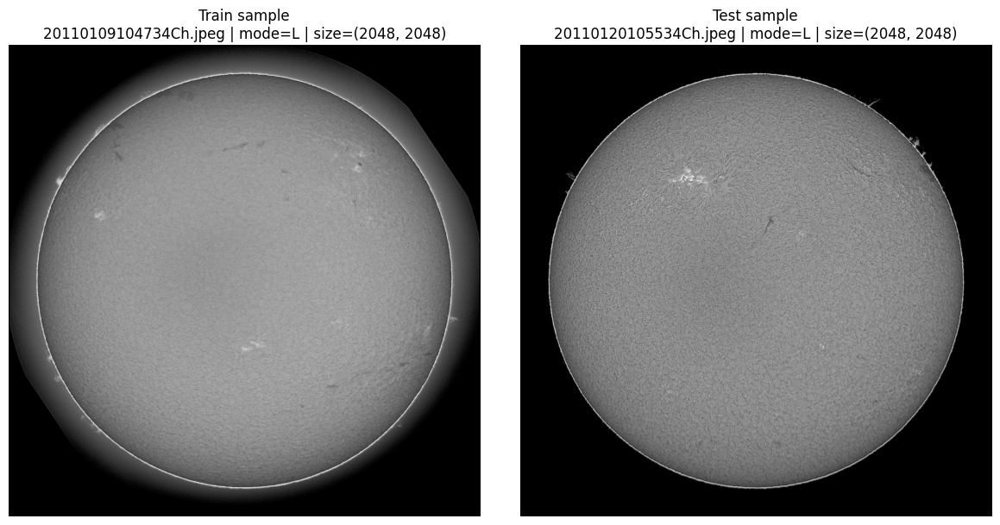


=== Instrument counts by split ===


instrument,Bh,Ch,Lh,Mh,Th,Uh
split,,,,,,
test,33,33,34,26,27,27
train,118,125,127,125,110,102


In [27]:
import os, sys, glob, json, platform, subprocess, warnings
warnings.filterwarnings("ignore")

# Install pycocotools only if missing
try:
    import pycocotools
except ImportError:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "pycocotools"], check=True)
    import pycocotools

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from IPython.display import display

# ---------- Environment table ----------
gpu_ok = torch.cuda.is_available()
env = {
    "Python": platform.python_version(),
    "PyTorch": torch.__version__,
    "CUDA available": gpu_ok,
    "GPU": torch.cuda.get_device_name(0) if gpu_ok else "None",
    "GPU count": torch.cuda.device_count(),
    "GPU memory (GB)": round(torch.cuda.get_device_properties(0).total_memory / 1e9, 1) if gpu_ok else 0,
    "NumPy": np.__version__,
}
print("=== Environment ===")
display(pd.DataFrame(env.items(), columns=["Item", "Value"]))

# ---------- Locate the competition data ----------
ann_hits = glob.glob("/kaggle/input/**/MAGFiLO_1.0_Annotations_kaggle2026_train.json", recursive=True)
assert ann_hits, "Annotation JSON not found. Check that the competition data is attached under Input."
ANN_PATH = ann_hits[0]
ROOT = os.path.dirname(os.path.dirname(ANN_PATH))
TRAIN_DIR = os.path.join(ROOT, "train", "train_images")
TEST_DIR = os.path.join(ROOT, "test", "test_images")

train_files = sorted(glob.glob(os.path.join(TRAIN_DIR, "*.jp*g")))
test_files = sorted(glob.glob(os.path.join(TEST_DIR, "*.jp*g")))

paths = pd.DataFrame({
    "Item": ["Root", "Annotations", "Train dir", "Test dir", "# train images", "# test images"],
    "Value": [ROOT, ANN_PATH, TRAIN_DIR, TEST_DIR, len(train_files), len(test_files)],
})
print("\n=== Data locations ===")
display(paths)

# ---------- Output dirs ----------
WORK = "/kaggle/working"
os.makedirs(f"{WORK}/ckpt", exist_ok=True)
os.makedirs(f"{WORK}/figs", exist_ok=True)

# ---------- Visual: first train and first test image, side by side ----------
from PIL import Image
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
for ax, f, title in zip(axes, [train_files[0], test_files[0]], ["Train sample", "Test sample"]):
    im = Image.open(f)
    ax.imshow(im, cmap="gray")
    ax.set_title(f"{title}\n{os.path.basename(f)} | mode={im.mode} | size={im.size}")
    ax.axis("off")
plt.tight_layout()
plt.show()

# ---------- Filename decoding check (YYYYMMDDHHMMSSII) ----------
def decode_name(fn):
    b = os.path.splitext(os.path.basename(fn))[0]
    return {"date": b[:8], "time": b[8:14], "instrument": b[14:16]}

inst = pd.DataFrame([decode_name(f) for f in train_files + test_files])
inst["split"] = ["train"] * len(train_files) + ["test"] * len(test_files)
print("\n=== Instrument counts by split ===")
display(inst.groupby(["split", "instrument"]).size().unstack(fill_value=0))

## 2. Annotation audit
Before modeling, I want to know:
- How many annotation records exist, and how many annotators label each image (the same image can appear several times, once per annotator batch)
- Filaments per image, filament area, and bounding-box shape distributions
- How many polygons are tiny (hard for any model and costly for PQ)
- How much annotators agree with each other (a practical ceiling for Dice and PQ)
- A visual check that polygons line up with the images

=== JSON top-level ===


,licenses,categories,images,annotations
count,3,4,1154,8199


Categories: {1: 'Left', 2: 'Right', 3: 'Unidentifiable', 4: 'Ambiguous'}

=== Image records ===


,image records,unique image files,unique annotators/batches,annotation records,images with 0 filaments,mean filaments / record
0,1154,707,37,8199,0,7.1



Train files without annotation record: 0
Annotation records without a train file: 0

=== Annotator sets per image file ===


...

,area,bw,bh,bbox_aspect,bbox_fill
count,8199.0,8199.0,8199.0,8199.0,8199.0
mean,2119.8,103.2,91.8,1.4,0.3
std,2741.7,93.0,72.0,1.0,0.1
min,9.0,3.8,3.5,0.1,0.0
5%,316.9,24.0,23.7,0.3,0.1
25%,670.0,46.4,43.6,0.7,0.2
50%,1228.0,74.5,69.6,1.1,0.2
75%,2438.0,126.2,116.6,1.8,0.4
95%,6946.8,280.9,230.7,3.3,0.6
max,37739.0,1067.3,709.8,12.8,0.9



=== Category counts ===


,count
cat,
Unidentifiable,3074
Right,2590
Left,2535



=== Fraction of filaments below area threshold (px) ===


,fraction below
100,0.001
500,0.154
1000,0.413
5000,0.910


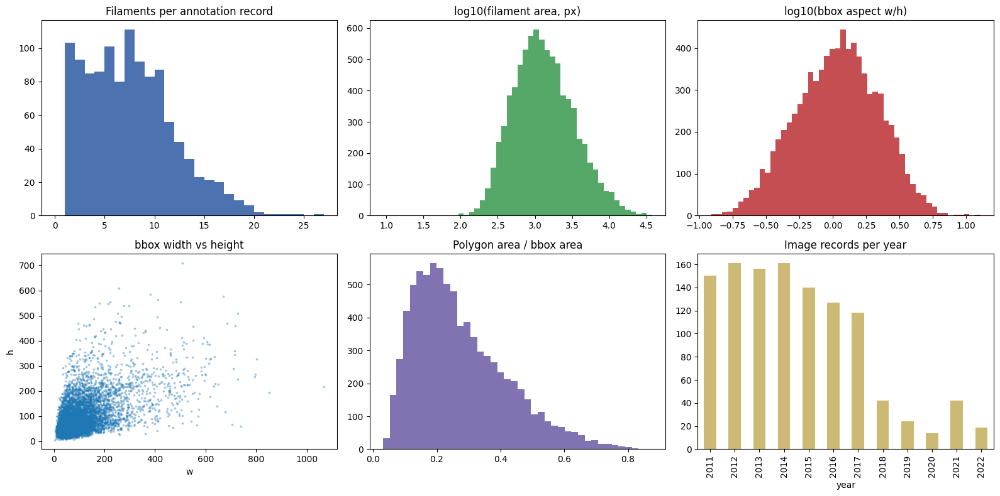

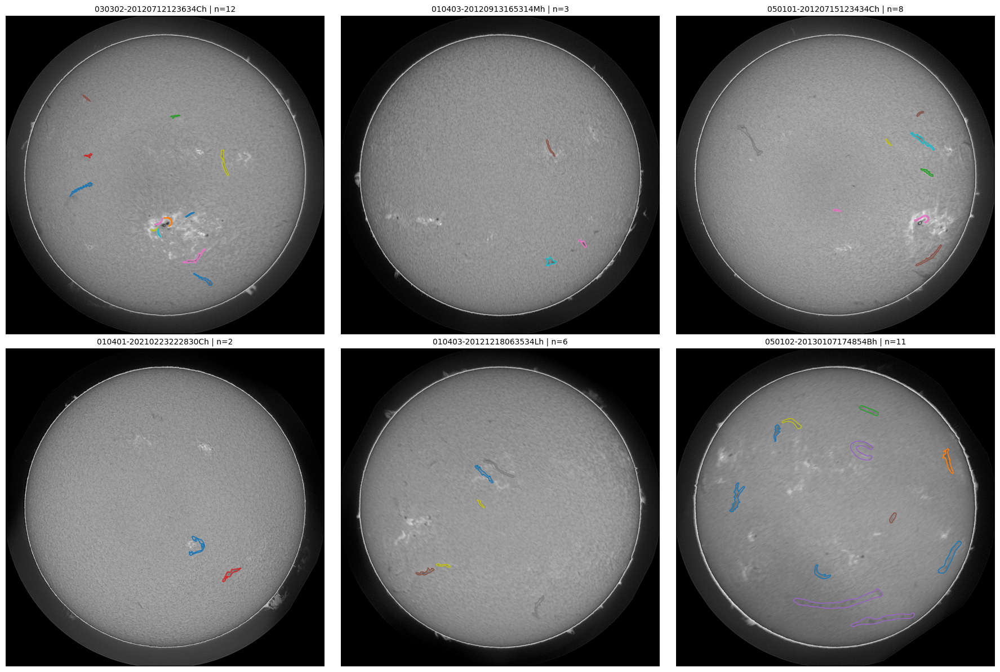


=== Annotator-vs-annotator agreement (semantic, 2 annotators per image) ===


,dice,iou,n_a,n_b
count,40.000,40.000,40.000,40.000
mean,0.613,0.460,6.250,6.525
std,0.172,0.153,4.516,4.344
min,0.000,0.000,1.000,1.000
25%,0.599,0.428,2.750,2.750
50%,0.656,0.488,5.500,7.000
75%,0.715,0.557,9.250,9.000
max,0.828,0.706,17.000,17.000


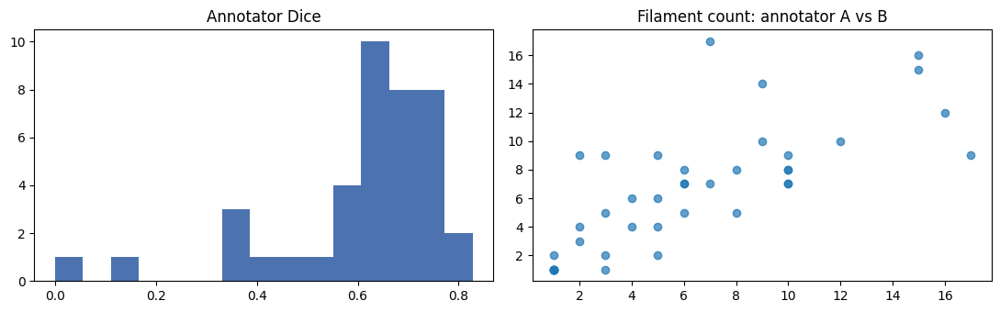

In [28]:
from pycocotools import mask as mu
import cv2

with open(ANN_PATH) as f:
    coco = json.load(f)

print("=== JSON top-level ===")
display(pd.DataFrame({k: [len(v) if isinstance(v, (list, dict)) else v] for k, v in coco.items()
                      if k in ["images", "annotations", "categories", "licenses"]}, index=["count"]))
print("Categories:", {c["id"]: c["name"] for c in coco["categories"]})

img_df = pd.DataFrame(coco["images"])
ann_df = pd.DataFrame(coco["annotations"])
ann_df[["bx", "by", "bw", "bh"]] = pd.DataFrame(ann_df["bbox"].tolist(), index=ann_df.index)

# image id looks like "010101-20150125172714Mh": annotator batch + image stem
img_df["stem"] = img_df["file_name"].str.replace(r"\.jpe?g$", "", regex=True)
img_df["annotator"] = img_df["id"].astype(str).str.split("-").str[0]
img_df["n_filaments"] = img_df["id"].map(ann_df.groupby("image_id").size()).fillna(0).astype(int)

print("\n=== Image records ===")
display(pd.DataFrame({
    "image records": [len(img_df)],
    "unique image files": [img_df["file_name"].nunique()],
    "unique annotators/batches": [img_df["annotator"].nunique()],
    "annotation records": [len(ann_df)],
    "images with 0 filaments": [(img_df["n_filaments"] == 0).sum()],
    "mean filaments / record": [round(img_df["n_filaments"].mean(), 2)],
}))

# Do all train files have annotations, and vice versa?
train_stems = {os.path.splitext(os.path.basename(f))[0] for f in train_files}
ann_stems = set(img_df["stem"])
print(f"\nTrain files without annotation record: {len(train_stems - ann_stems)}")
print(f"Annotation records without a train file: {len(ann_stems - train_stems)}")

# Annotators per image file
per_file = img_df.groupby("stem")["annotator"].nunique()
print("\n=== Annotator sets per image file ===")
display(per_file.value_counts().sort_index().rename("n_images").to_frame())

# Geometry stats
ann_df["bbox_aspect"] = ann_df["bw"] / ann_df["bh"].clip(lower=1)
ann_df["bbox_fill"] = ann_df["area"] / (ann_df["bw"] * ann_df["bh"]).clip(lower=1)
ann_df["cat"] = ann_df["category_id"].map({c["id"]: c["name"] for c in coco["categories"]})
print("\n=== Annotation geometry ===")
display(ann_df[["area", "bw", "bh", "bbox_aspect", "bbox_fill"]].describe(
    percentiles=[.05, .25, .5, .75, .95]).round(1))
print("\n=== Category counts ===")
display(ann_df["cat"].value_counts().to_frame("count"))

small = pd.Series({t: (ann_df["area"] < t).mean() for t in [100, 500, 1000, 5000]}, name="fraction below")
print("\n=== Fraction of filaments below area threshold (px) ===")
display(small.round(3).to_frame())

# ---------- Plots ----------
fig, ax = plt.subplots(2, 3, figsize=(16, 8))
ax[0, 0].hist(img_df["n_filaments"], bins=range(0, img_df["n_filaments"].max() + 2), color="#4c72b0")
ax[0, 0].set_title("Filaments per annotation record")
ax[0, 1].hist(np.log10(ann_df["area"].clip(lower=1)), bins=50, color="#55a868")
ax[0, 1].set_title("log10(filament area, px)")
ax[0, 2].hist(np.log10(ann_df["bbox_aspect"].clip(lower=0.01)), bins=50, color="#c44e52")
ax[0, 2].set_title("log10(bbox aspect w/h)")
ax[1, 0].scatter(ann_df["bw"], ann_df["bh"], s=3, alpha=.3)
ax[1, 0].set_title("bbox width vs height"); ax[1, 0].set_xlabel("w"); ax[1, 0].set_ylabel("h")
ax[1, 1].hist(ann_df["bbox_fill"], bins=40, color="#8172b2")
ax[1, 1].set_title("Polygon area / bbox area")
img_df.assign(year=img_df["stem"].str[:4]).groupby("year").size().plot.bar(ax=ax[1, 2], color="#ccb974")
ax[1, 2].set_title("Image records per year")
plt.tight_layout()
plt.savefig(f"{WORK}/figs/audit_stats.png", dpi=110)
plt.show()

# ---------- Polygon -> mask helpers (reused later) ----------
H = W = 2048
def ann_to_mask(a):
    rle = mu.merge(mu.frPyObjects(a["segmentation"], H, W))
    return mu.decode(rle)

ann_by_img = ann_df.groupby("image_id")
def record_mask(image_id):
    m = np.zeros((H, W), np.uint8)
    if image_id in ann_by_img.groups:
        for _, a in ann_by_img.get_group(image_id).iterrows():
            m |= ann_to_mask(a)
    return m

# ---------- Visual check: GT overlays on 6 random records ----------
rng = np.random.default_rng(0)
sample = img_df[img_df["n_filaments"] > 0].sample(6, random_state=0)
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
for ax_, (_, r) in zip(axes.ravel(), sample.iterrows()):
    im = np.array(Image.open(os.path.join(TRAIN_DIR, r["file_name"])).convert("L"))
    ax_.imshow(im, cmap="gray")
    for _, a in ann_by_img.get_group(r["id"]).iterrows():
        m = ann_to_mask(a)
        cs, _ = cv2.findContours(m, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
        for c in cs:
            ax_.plot(c[:, 0, 1 - 1], c[:, 0, 1], lw=1.2, color=plt.cm.tab10(rng.integers(10)))
    ax_.set_title(f"{r['id']} | n={r['n_filaments']}", fontsize=10)
    ax_.axis("off")
plt.tight_layout()
plt.savefig(f"{WORK}/figs/gt_overlays.png", dpi=90)
plt.show()

# ---------- Inter-annotator agreement (ceiling estimate) ----------
multi = img_df.groupby("stem").filter(lambda g: g["annotator"].nunique() >= 2)
stems = multi["stem"].drop_duplicates().sample(min(40, multi["stem"].nunique()), random_state=0)
rows = []
for s in stems:
    recs = multi[multi["stem"] == s]["id"].tolist()[:2]
    a, b = record_mask(recs[0]) > 0, record_mask(recs[1]) > 0
    inter, union = (a & b).sum(), (a | b).sum()
    rows.append({"stem": s, "dice": 2 * inter / max(a.sum() + b.sum(), 1),
                 "iou": inter / max(union, 1),
                 "n_a": (img_df["id"] == recs[0]).sum() and img_df.loc[img_df["id"] == recs[0], "n_filaments"].iloc[0],
                 "n_b": img_df.loc[img_df["id"] == recs[1], "n_filaments"].iloc[0]})
agree = pd.DataFrame(rows)
print("\n=== Annotator-vs-annotator agreement (semantic, 2 annotators per image) ===")
display(agree[["dice", "iou", "n_a", "n_b"]].describe().round(3))
fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
ax[0].hist(agree["dice"], bins=15, color="#4c72b0"); ax[0].set_title("Annotator Dice")
ax[1].scatter(agree["n_a"], agree["n_b"], alpha=.7); ax[1].set_title("Filament count: annotator A vs B")
plt.tight_layout(); plt.show()

## 3. Folds, consensus targets, PQ metric, and the annotator ceiling
- **Grouped 5-fold split** by observation date, stratified by instrument, so no day appears in both train and validation
- **Cache** all images (uint8) and **soft consensus masks** (mean of annotator masks, stored as 0-255) to disk-backed arrays
- **Instrument brightness table** to decide on normalization (the six GONG sites may differ a lot)
- **Panoptic Quality** implementation: match on IoU > 0.5, PQ = sum(IoU of matches) / (TP + 0.5 FP + 0.5 FN)
- **Ceiling:** PQ between two human annotators of the same image. A model cannot reasonably be expected to beat this.

=== Folds (grouped by date, no leakage) ===


,images,dates,multi_annotated,mean_filaments,Bh,Ch,Lh,Mh,Th,Uh
fold,,,,,,,,,,
0,144,130,60,6.85,27,26,18,21,25,27
1,141,132,60,7.61,25,27,24,29,23,13
2,145,132,56,7.90,25,24,23,26,29,18
3,140,132,56,7.20,20,22,34,29,18,17
4,137,130,64,7.21,21,26,28,20,15,27



Cached 707 images + soft masks in 79s -> /tmp  (3.0 GB each)

=== Foreground rate and pixel agreement by # annotators ===


,images,fg_pct,frac_pixels_all_agree
n_ann,,,
1,411,0.350,1.000
2,145,0.487,0.467
3,151,0.591,0.306



=== Image intensity by instrument (mean over images; std = spread across images) ===


mean             std        p1              p99     
                 mean  std       mean  std mean  std        mean  std
instrument                                                           
Bh          85.599998  3.4  56.200001  2.5  0.0  0.0  154.500000  4.8
Ch          82.699997  2.9  58.200001  1.6  0.0  0.0  156.199997  4.5
Lh          81.500000  2.0  57.299999  2.0  0.0  0.0  154.899994  4.1
Mh          81.800003  2.6  57.799999  2.4  0.0  0.0  153.800003  3.2
Th          85.800003  2.7  53.299999  2.4  0.0  0.0  153.500000  3.6
Uh          83.400002  2.0  57.099998  1.5  0.0  0.0  153.300003  3.3

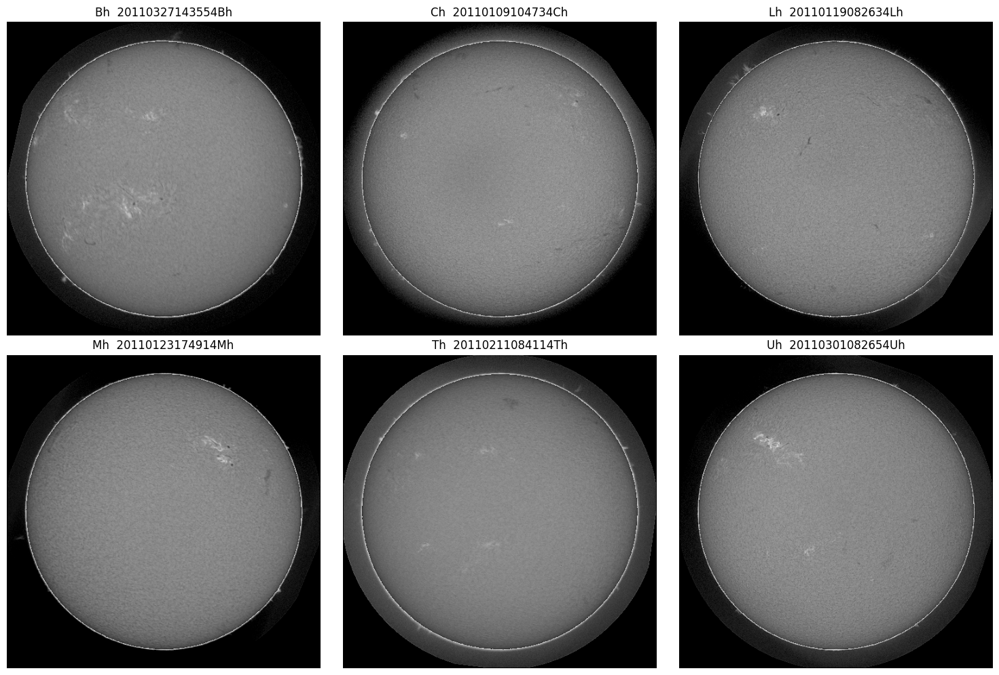

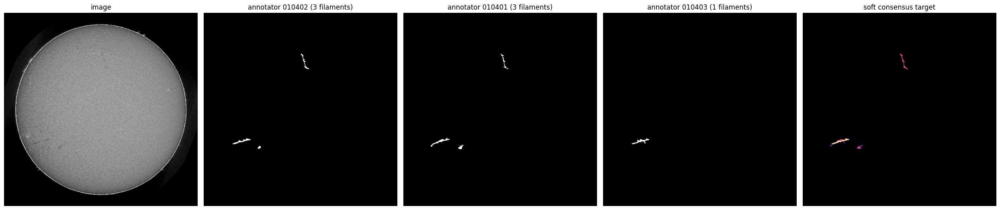


=== Annotator-vs-annotator PQ ceiling (598 pairs, 296 images) ===


,mean per-pair PQ,pooled PQ,mean SQ,mean RQ,median PQ
0,0.341,0.34,0.597,0.538,0.342


PQ ceiling by instrument:


,pairs,PQ,SQ,RQ
instrument,,,,
Bh,106,0.367,0.607,0.586
Ch,93,0.335,0.602,0.530
Lh,110,0.350,0.601,0.545
Mh,107,0.325,0.582,0.516
Th,95,0.338,0.585,0.526
Uh,87,0.326,0.605,0.516


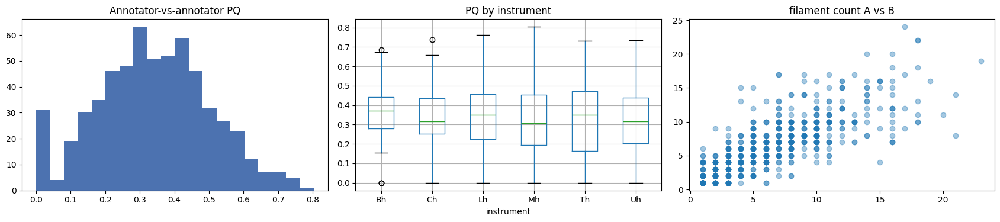

In [29]:
import time, itertools
from sklearn.model_selection import StratifiedGroupKFold

SEED = 42
np.random.seed(SEED); torch.manual_seed(SEED)
CACHE = "/kaggle/temp" if os.path.isdir("/kaggle/temp") else "/tmp"
os.makedirs(CACHE, exist_ok=True)

# ---------- Per-record RLEs (one RLE per filament polygon) ----------
rle_by_rec = {rec: [mu.merge(mu.frPyObjects(s, H, W)) for s in g["segmentation"]]
              for rec, g in ann_df.groupby("image_id")}

# ---------- One row per unique image (stem) ----------
nfil = dict(zip(img_df["id"], img_df["n_filaments"]))
fname = img_df.drop_duplicates("stem").set_index("stem")["file_name"]
stem_df = (img_df.groupby("stem").agg(records=("id", list), n_ann=("id", "size")).reset_index())
stem_df["date"] = stem_df["stem"].str[:8]
stem_df["instrument"] = stem_df["stem"].str[14:16]
stem_df["n_fil"] = stem_df["records"].map(lambda r: np.mean([nfil[i] for i in r]))

# ---------- Grouped, instrument-stratified folds ----------
sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=SEED)
stem_df["fold"] = -1
for k, (_, va) in enumerate(sgkf.split(stem_df, stem_df["instrument"], groups=stem_df["date"])):
    stem_df.loc[va, "fold"] = k
assert (stem_df.groupby("date")["fold"].nunique() == 1).all(), "date leakage across folds"

fold_tbl = stem_df.groupby("fold").agg(images=("stem", "size"), dates=("date", "nunique"),
                                       multi_annotated=("n_ann", lambda s: (s > 1).sum()),
                                       mean_filaments=("n_fil", "mean")).round(2)
fold_tbl = fold_tbl.join(stem_df.groupby(["fold", "instrument"]).size().unstack(fill_value=0))
print("=== Folds (grouped by date, no leakage) ===")
display(fold_tbl)

# ---------- Build disk-backed caches: images + soft consensus masks ----------
N = len(stem_df)
X = np.lib.format.open_memmap(f"{CACHE}/X.npy", mode="w+", dtype=np.uint8, shape=(N, H, W))
Y = np.lib.format.open_memmap(f"{CACHE}/Y.npy", mode="w+", dtype=np.uint8, shape=(N, H, W))
t0 = time.time()
for i, r in stem_df.iterrows():
    im = cv2.imread(os.path.join(TRAIN_DIR, fname[r["stem"]]), cv2.IMREAD_GRAYSCALE)
    assert im is not None and im.shape == (H, W), (r["stem"], None if im is None else im.shape)
    X[i] = im
    acc = np.zeros((H, W), np.float32)
    for rec in r["records"]:
        acc += mu.decode(mu.merge(rle_by_rec[rec]))
    Y[i] = np.round(acc / len(r["records"]) * 255).astype(np.uint8)
X.flush(); Y.flush()
print(f"\nCached {N} images + soft masks in {time.time() - t0:.0f}s -> {CACHE}  "
      f"({X.nbytes / 1e9:.1f} GB each)")

# ---------- Label statistics: pixel-level agreement and foreground rate ----------
rows = []
for i, r in stem_df.iterrows():
    y = Y[i]
    any_ = (y > 0).sum(); full = (y == 255).sum()
    rows.append({"n_ann": r["n_ann"], "fg_any_pct": 100 * any_ / (H * W),
                 "pixel_agreement": full / max(any_, 1)})
lab = pd.DataFrame(rows)
print("\n=== Foreground rate and pixel agreement by # annotators ===")
display(lab.groupby("n_ann").agg(images=("n_ann", "size"), fg_pct=("fg_any_pct", "mean"),
                                 frac_pixels_all_agree=("pixel_agreement", "mean")).round(3))

# ---------- Instrument brightness (decide normalization) ----------
bs = []
for i, r in stem_df.iterrows():
    s = X[i][::8, ::8].astype(np.float32)
    bs.append({"instrument": r["instrument"], "mean": s.mean(), "std": s.std(),
               "p1": np.percentile(s, 1), "p99": np.percentile(s, 99)})
bright = pd.DataFrame(bs).groupby("instrument").agg(["mean", "std"]).round(1)
print("\n=== Image intensity by instrument (mean over images; std = spread across images) ===")
display(bright)

# ---------- Visual 1: one image per instrument ----------
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
for ax_, ins in zip(axes.ravel(), sorted(stem_df["instrument"].unique())):
    i = stem_df.index[stem_df["instrument"] == ins][0]
    ax_.imshow(X[i][::4, ::4], cmap="gray", vmin=0, vmax=255)
    ax_.set_title(f"{ins}  {stem_df.loc[i, 'stem']}"); ax_.axis("off")
plt.tight_layout(); plt.savefig(f"{WORK}/figs/instruments.png", dpi=80); plt.show()

# ---------- Visual 2: image vs each annotator vs consensus (3-annotator image) ----------
i = stem_df.index[stem_df["n_ann"] == 3][0]
recs = stem_df.loc[i, "records"]
fig, axes = plt.subplots(1, 5, figsize=(25, 5.5))
axes[0].imshow(X[i][::4, ::4], cmap="gray"); axes[0].set_title("image")
for ax_, rec in zip(axes[1:4], recs):
    ax_.imshow(mu.decode(mu.merge(rle_by_rec[rec]))[::4, ::4], cmap="gray")
    ax_.set_title(f"annotator {rec.split('-')[0]} ({len(rle_by_rec[rec])} filaments)")
axes[4].imshow(Y[i][::4, ::4], cmap="magma"); axes[4].set_title("soft consensus target")
for a in axes: a.axis("off")
plt.tight_layout(); plt.savefig(f"{WORK}/figs/consensus.png", dpi=70); plt.show()

# ---------- Panoptic Quality ----------
def pq_rles(gt, pr, thr=0.5):
    """PQ for one image. gt/pr: lists of COCO RLEs. Returns dict incl. iou_sum for pooled PQ."""
    if len(gt) == 0 and len(pr) == 0:
        return dict(pq=1.0, sq=1.0, rq=1.0, tp=0, fp=0, fn=0, iou_sum=0.0)
    if len(gt) == 0 or len(pr) == 0:
        return dict(pq=0.0, sq=0.0, rq=0.0, tp=0, fp=len(pr), fn=len(gt), iou_sum=0.0)
    iou = np.asarray(mu.iou(pr, gt, [0] * len(gt)))
    pairs = sorted(map(tuple, np.argwhere(iou > thr)), key=lambda p: -iou[p])
    up, ug, s, tp = set(), set(), 0.0, 0
    for p, g in pairs:
        if p in up or g in ug: continue
        up.add(p); ug.add(g); s += iou[p, g]; tp += 1
    fp, fn = len(pr) - tp, len(gt) - tp
    d = tp + 0.5 * fp + 0.5 * fn
    return dict(pq=s / d, sq=s / tp if tp else 0.0, rq=tp / d, tp=tp, fp=fp, fn=fn, iou_sum=s)

def pooled_pq(df):
    d = df["tp"].sum() + 0.5 * df["fp"].sum() + 0.5 * df["fn"].sum()
    return df["iou_sum"].sum() / d

# ---------- Ceiling: annotator vs annotator ----------
rows = []
for _, r in stem_df[stem_df["n_ann"] >= 2].iterrows():
    for a, b in itertools.combinations(r["records"], 2):
        m = pq_rles(rle_by_rec[a], rle_by_rec[b])
        m.update(stem=r["stem"], instrument=r["instrument"], fold=r["fold"],
                 n_a=len(rle_by_rec[a]), n_b=len(rle_by_rec[b]))
        rows.append(m)
ceil = pd.DataFrame(rows)

print(f"\n=== Annotator-vs-annotator PQ ceiling ({len(ceil)} pairs, {ceil['stem'].nunique()} images) ===")
display(pd.DataFrame({"mean per-pair PQ": [ceil["pq"].mean()], "pooled PQ": [pooled_pq(ceil)],
                      "mean SQ": [ceil["sq"].mean()], "mean RQ": [ceil["rq"].mean()],
                      "median PQ": [ceil["pq"].median()]}).round(3))
print("PQ ceiling by instrument:")
display(ceil.groupby("instrument").agg(pairs=("pq", "size"), PQ=("pq", "mean"),
                                       SQ=("sq", "mean"), RQ=("rq", "mean")).round(3))

fig, ax = plt.subplots(1, 3, figsize=(17, 4))
ax[0].hist(ceil["pq"], bins=20, color="#4c72b0"); ax[0].set_title("Annotator-vs-annotator PQ")
ceil.boxplot(column="pq", by="instrument", ax=ax[1]); ax[1].set_title("PQ by instrument"); plt.suptitle("")
ax[2].scatter(ceil["n_a"], ceil["n_b"], alpha=.4); ax[2].set_title("filament count A vs B")
plt.tight_layout(); plt.show()

## 4. Dataset and augmentations
- **Fold 0** as validation for now (other folds reuse the same code later)
- **Training crops:** 768 px at random scale (0.75x to 1.33x), so the model sees filaments at slightly different sizes
- **Foreground-biased sampling:** 60% of crops are centered on a labeled pixel, since filaments cover only about 0.4% of the frame
- **Augmentations:** flips, 90-degree rotations (exact for a solar image), brightness/contrast, gamma, light blur and noise
- **Target:** soft consensus mask in [0, 1]
- **Normalization:** global (x - 83) / 57
- **Checks:** a visual batch, foreground statistics for biased vs random crops, and loader throughput

=== Split (fold 0 held out) ===


,split,images,annotation records
0,train,563,920
1,val,144,234



=== Crop foreground statistics ===


,fg-biased (p=0.6),uniform random
crops,200.00,200.00
% crops with any foreground,86.00,76.00
mean fg pixels (%),1.05,0.61
median fg pixels (%),0.82,0.37



Batch tensors: x (8, 1, 768, 768) torch.float32, y (8, 1, 768, 768) torch.float32
x mean/std: 0.682 / 0.612   y range: [0.00, 1.00]
Throughput: 84.3 crops/s  (0.09 s/batch of 8)


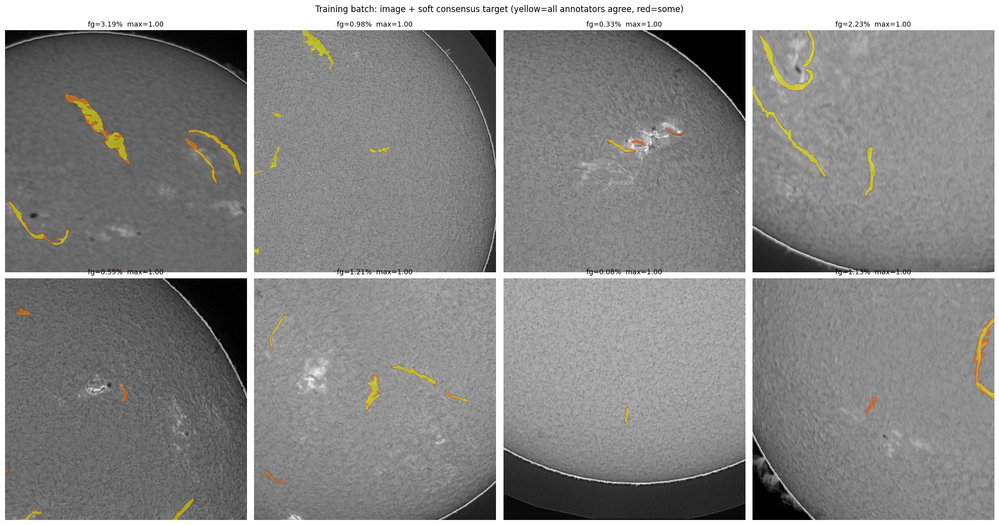

In [30]:
from torch.utils.data import Dataset, DataLoader

FOLD, CROP = 0, 768
MEAN, STD = 83.0, 57.0

tr_idx = stem_df.index[stem_df["fold"] != FOLD].to_numpy()
va_idx = stem_df.index[stem_df["fold"] == FOLD].to_numpy()
print("=== Split (fold %d held out) ===" % FOLD)
display(pd.DataFrame({"split": ["train", "val"], "images": [len(tr_idx), len(va_idx)],
                      "annotation records": [stem_df.loc[tr_idx, "n_ann"].sum(), stem_df.loc[va_idx, "n_ann"].sum()]}))

class FilamentDS(Dataset):
    def __init__(self, idx, crop=CROP, epoch_len=None, fg_prob=0.6, aug=True):
        self.idx, self.crop, self.fg_prob, self.aug = np.asarray(idx), crop, fg_prob, aug
        self.epoch_len = epoch_len or len(self.idx)
        self.X = self.Y = None
        # foreground coordinates on an 8x-downsampled grid, used for biased crop centers
        Ym = np.load(f"{CACHE}/Y.npy", mmap_mode="r")
        self.fg = {int(i): np.argwhere(Ym[i][::8, ::8] > 0) * 8 for i in self.idx}

    def _open(self):
        if self.X is None:
            self.X = np.load(f"{CACHE}/X.npy", mmap_mode="r")
            self.Y = np.load(f"{CACHE}/Y.npy", mmap_mode="r")

    def __len__(self):
        return self.epoch_len

    def __getitem__(self, k):
        self._open()
        rng = np.random.default_rng()
        i = int(self.idx[rng.integers(len(self.idx))])
        s = rng.uniform(0.75, 1.33) if self.aug else 1.0
        src = int(min(self.crop * s, H))
        fg = self.fg[i]
        if len(fg) and rng.random() < self.fg_prob:
            cy, cx = fg[rng.integers(len(fg))] + rng.integers(0, 8, 2)
        else:
            cy, cx = rng.integers(0, H, 2)
        y0 = int(np.clip(cy - src // 2, 0, H - src)); x0 = int(np.clip(cx - src // 2, 0, W - src))
        x = np.array(self.X[i, y0:y0 + src, x0:x0 + src], dtype=np.float32)
        y = np.array(self.Y[i, y0:y0 + src, x0:x0 + src], dtype=np.float32) / 255.0
        if src != self.crop:
            x = cv2.resize(x, (self.crop, self.crop), interpolation=cv2.INTER_LINEAR)
            y = cv2.resize(y, (self.crop, self.crop), interpolation=cv2.INTER_LINEAR)
        if self.aug:
            kr = rng.integers(4)
            x, y = np.rot90(x, kr), np.rot90(y, kr)
            if rng.random() < 0.5: x, y = x[:, ::-1], y[:, ::-1]
            if rng.random() < 0.5: x, y = x[::-1], y[::-1]
            x = np.clip(x * rng.uniform(0.85, 1.15) + rng.uniform(-12, 12), 0, 255)
            if rng.random() < 0.5:
                x = 255.0 * (x / 255.0) ** rng.uniform(0.8, 1.25)
            if rng.random() < 0.2:
                x = cv2.GaussianBlur(np.ascontiguousarray(x), (0, 0), rng.uniform(0.5, 1.2))
            if rng.random() < 0.2:
                x = np.clip(x + rng.normal(0, rng.uniform(1, 4), x.shape), 0, 255)
        x = (np.ascontiguousarray(x) - MEAN) / STD
        return torch.from_numpy(x[None].astype(np.float32)), torch.from_numpy(np.ascontiguousarray(y)[None].astype(np.float32))

train_ds = FilamentDS(tr_idx, epoch_len=len(tr_idx) * 4)
train_dl = DataLoader(train_ds, batch_size=8, shuffle=False, num_workers=4,
                      pin_memory=True, persistent_workers=True, drop_last=True)

# ---------- Foreground statistics: biased vs random crops ----------
def crop_stats(ds, n=200):
    fgs = []
    for _ in range(n):
        _, y = ds[0]
        fgs.append(float((y > 0).float().mean()) * 100)
    fgs = np.array(fgs)
    return {"crops": n, "% crops with any foreground": round((fgs > 0).mean() * 100, 1),
            "mean fg pixels (%)": round(fgs.mean(), 2), "median fg pixels (%)": round(np.median(fgs), 2)}

stats = pd.DataFrame({
    "fg-biased (p=0.6)": crop_stats(FilamentDS(tr_idx, fg_prob=0.6)),
    "uniform random": crop_stats(FilamentDS(tr_idx, fg_prob=0.0)),
})
print("\n=== Crop foreground statistics ===")
display(stats)

# ---------- Loader throughput ----------
t0 = time.time(); nb = 25
for b, (xb, yb) in enumerate(train_dl):
    if b == nb - 1: break
dt = time.time() - t0
print(f"\nBatch tensors: x {tuple(xb.shape)} {xb.dtype}, y {tuple(yb.shape)} {yb.dtype}")
print(f"x mean/std: {xb.mean():.3f} / {xb.std():.3f}   y range: [{yb.min():.2f}, {yb.max():.2f}]")
print(f"Throughput: {nb * 8 / dt:.1f} crops/s  ({dt / nb:.2f} s/batch of 8)")

# ---------- Visual: batch with mask overlays ----------
fig, axes = plt.subplots(2, 4, figsize=(20, 10.5))
for ax_, j in zip(axes.ravel(), range(8)):
    im = xb[j, 0].numpy() * STD + MEAN
    ax_.imshow(im, cmap="gray", vmin=0, vmax=255)
    ov = np.ma.masked_where(yb[j, 0].numpy() < 0.05, yb[j, 0].numpy())
    ax_.imshow(ov, cmap="autumn", alpha=0.55, vmin=0, vmax=1)
    ax_.set_title(f"fg={100 * float((yb[j] > 0).float().mean()):.2f}%  max={float(yb[j].max()):.2f}", fontsize=10)
    ax_.axis("off")
plt.suptitle("Training batch: image + soft consensus target (yellow=all annotators agree, red=some)", y=0.995)
plt.tight_layout(); plt.savefig(f"{WORK}/figs/train_batch.png", dpi=70); plt.show()

## 5. Model and loss
- **Architecture:** U-Net with a pretrained CNN encoder (`segmentation_models_pytorch`), 1-channel input, full-resolution logit output
- **Pretrained weights:** tried first; if the notebook has no internet it falls back to random init and says so
- **Loss:** BCE + soft Dice on the consensus target (BCE handles the 0.3% foreground imbalance poorly alone; Dice fixes that)
- **Precision:** fp16 autocast with GradScaler (T4 has no fast bf16)
- **Benchmark:** parameters, train-step time, and peak GPU memory for 3 encoders at batch 8 x 768 px
- **Sanity check:** overfit one batch for 60 steps; loss must drop sharply and predictions must match the targets

smp version: 0.5.0

=== Encoder benchmark (T4, fp16, batch 8 x 768x768) ===


,encoder,params (M),s / step (bs 8),peak mem (GB),est. min / 1000 steps
0,resnet34,24.4,0.393,5.1,6.6
1,resnet50,32.5,0.574,8.0,9.6
2,resnext50_32x4d,32.0,0.660,9.2,11.0



Chosen: Unet/resnet34 | weights: imagenet | params: 24.4M
output shape: (2, 1, 768, 768) | dtype: torch.float16

=== Overfit test (selected steps) ===


,loss,bce,soft_dice_loss,hard_dice
step,,,,
0,2.6663,1.6845,0.9817,0.0192
9,1.6814,0.7001,0.9812,0.0245
19,1.5413,0.5650,0.9762,0.3767
29,1.3790,0.4139,0.9652,0.6305
39,1.2669,0.3128,0.9541,0.6976
49,1.1513,0.2186,0.9327,0.7618
59,1.0516,0.1518,0.8998,0.7908


PASS: model can fit a batch


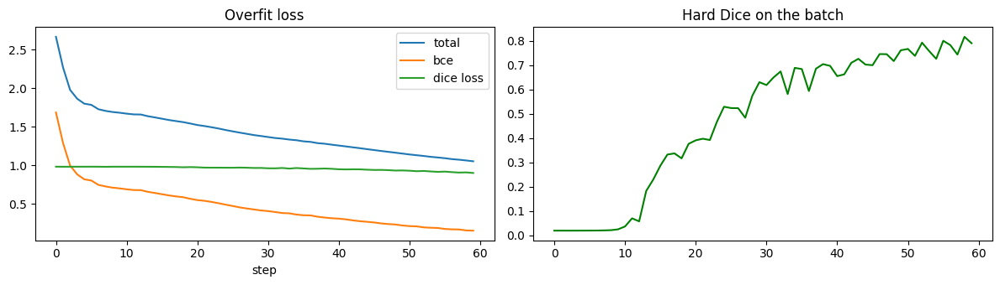

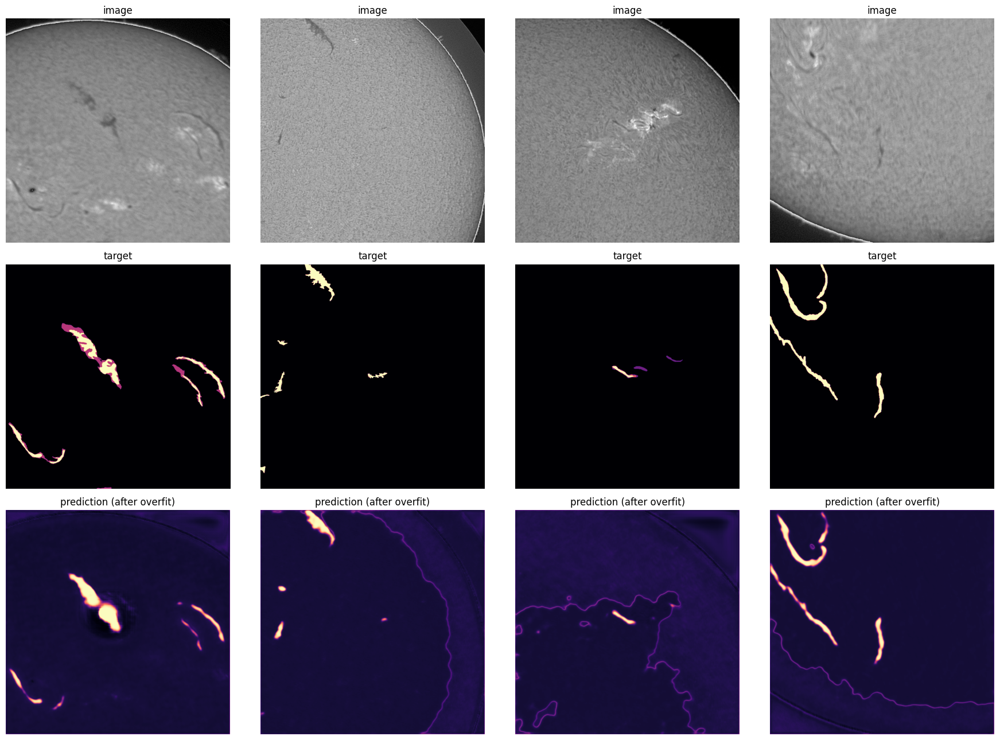

In [31]:
import subprocess, sys, gc, importlib
import torch.nn as nn, torch.nn.functional as F

try:
    import segmentation_models_pytorch as smp
except ImportError:
    r = subprocess.run([sys.executable, "-m", "pip", "install", "-q", "segmentation-models-pytorch"],
                       capture_output=True, text=True)
    print(r.stderr[-400:] if r.returncode else "installed segmentation-models-pytorch")
    smp = importlib.import_module("segmentation_models_pytorch")
print("smp version:", smp.__version__)

dev = torch.device("cuda")

def build_model(encoder="resnet34", pretrained=True):
    w = "imagenet" if pretrained else None
    try:
        m = smp.Unet(encoder, encoder_weights=w, in_channels=1, classes=1)
        return m, ("imagenet" if pretrained else "random")
    except Exception as e:
        print(f"  [{encoder}] pretrained download failed ({type(e).__name__}); using random init")
        return smp.Unet(encoder, encoder_weights=None, in_channels=1, classes=1), "random (fallback)"

def seg_loss(logits, y, eps=1.0):
    logits = logits.float()
    bce = F.binary_cross_entropy_with_logits(logits, y)
    p = torch.sigmoid(logits)
    inter = (p * y).sum((1, 2, 3))
    dice = 1 - (2 * inter + eps) / (p.sum((1, 2, 3)) + y.sum((1, 2, 3)) + eps)
    return bce + dice.mean(), bce.detach(), dice.mean().detach()

# ---------- Encoder benchmark (random init: fast, no download) ----------
xb_, yb_ = xb.to(dev), yb.to(dev)
rows = []
for enc in ["resnet34", "resnet50", "resnext50_32x4d"]:
    try:
        m = smp.Unet(enc, encoder_weights=None, in_channels=1, classes=1).to(dev).to(memory_format=torch.channels_last)
        opt = torch.optim.AdamW(m.parameters(), 1e-3); sc = torch.cuda.amp.GradScaler()
        torch.cuda.reset_peak_memory_stats(); torch.cuda.synchronize()
        for k in range(6):
            if k == 2: torch.cuda.synchronize(); t0 = time.time()
            with torch.autocast("cuda", dtype=torch.float16):
                loss = seg_loss(m(xb_.contiguous(memory_format=torch.channels_last)), yb_)[0]
            opt.zero_grad(set_to_none=True); sc.scale(loss).backward(); sc.step(opt); sc.update()
        torch.cuda.synchronize(); dt = (time.time() - t0) / 4
        rows.append({"encoder": enc, "params (M)": round(sum(p.numel() for p in m.parameters()) / 1e6, 1),
                     "s / step (bs 8)": round(dt, 3), "peak mem (GB)": round(torch.cuda.max_memory_allocated() / 1e9, 1),
                     "est. min / 1000 steps": round(dt * 1000 / 60, 1)})
    except Exception as e:
        rows.append({"encoder": enc, "params (M)": None, "s / step (bs 8)": None,
                     "peak mem (GB)": None, "est. min / 1000 steps": f"failed: {type(e).__name__}"})
    del m; gc.collect(); torch.cuda.empty_cache()
print("\n=== Encoder benchmark (T4, fp16, batch 8 x 768x768) ===")
display(pd.DataFrame(rows))

# ---------- Build chosen model ----------
ENCODER = "resnet34"
model, wsrc = build_model(ENCODER, pretrained=True)
model = model.to(dev).to(memory_format=torch.channels_last)
print(f"\nChosen: Unet/{ENCODER} | weights: {wsrc} | params: {sum(p.numel() for p in model.parameters()) / 1e6:.1f}M")
with torch.no_grad(), torch.autocast("cuda", dtype=torch.float16):
    out = model(xb_[:2]); print("output shape:", tuple(out.shape), "| dtype:", out.dtype)

# ---------- Overfit-one-batch sanity test ----------
opt = torch.optim.AdamW(model.parameters(), 1e-3); sc = torch.cuda.amp.GradScaler()
hist = []
model.train()
for step in range(60):
    with torch.autocast("cuda", dtype=torch.float16):
        logits = model(xb_.contiguous(memory_format=torch.channels_last))
    loss, bce, dice = seg_loss(logits, yb_)
    opt.zero_grad(set_to_none=True); sc.scale(loss).backward(); sc.step(opt); sc.update()
    with torch.no_grad():
        p = (torch.sigmoid(logits.float()) > 0.5).float(); g = (yb_ > 0.5).float()
        hard_dice = ((2 * (p * g).sum() + 1) / (p.sum() + g.sum() + 1)).item()
    hist.append({"step": step, "loss": loss.item(), "bce": bce.item(), "soft_dice_loss": dice.item(), "hard_dice": hard_dice})
h = pd.DataFrame(hist)
print("\n=== Overfit test (selected steps) ===")
display(h.iloc[[0, 9, 19, 29, 39, 49, 59]].round(4).set_index("step"))
ok = h["hard_dice"].iloc[-1] > 0.6
print("PASS: model can fit a batch" if ok else "WARNING: weak fit; check loss/lr before training long")

fig, ax = plt.subplots(1, 2, figsize=(12, 3.5))
ax[0].plot(h["loss"], label="total"); ax[0].plot(h["bce"], label="bce"); ax[0].plot(h["soft_dice_loss"], label="dice loss")
ax[0].legend(); ax[0].set_title("Overfit loss"); ax[0].set_xlabel("step")
ax[1].plot(h["hard_dice"], color="green"); ax[1].set_title("Hard Dice on the batch")
plt.tight_layout(); plt.show()

model.eval()
with torch.no_grad(), torch.autocast("cuda", dtype=torch.float16):
    pr = torch.sigmoid(model(xb_.contiguous(memory_format=torch.channels_last)).float()).cpu().numpy()
fig, axes = plt.subplots(3, 4, figsize=(18, 13))
for c, j in enumerate(range(4)):
    axes[0, c].imshow(xb[j, 0] * STD + MEAN, cmap="gray"); axes[0, c].set_title("image")
    axes[1, c].imshow(yb[j, 0], cmap="magma", vmin=0, vmax=1); axes[1, c].set_title("target")
    axes[2, c].imshow(pr[j, 0], cmap="magma", vmin=0, vmax=1); axes[2, c].set_title("prediction (after overfit)")
for a in axes.ravel(): a.axis("off")
plt.tight_layout(); plt.savefig(f"{WORK}/figs/overfit_check.png", dpi=65); plt.show()

# reset: Cell 6 starts from a fresh model
del model, opt; gc.collect(); torch.cuda.empty_cache()

In [32]:
import importlib.metadata as md
pkgs = ["torch", "torchvision", "segmentation-models-pytorch", "timm", "numpy",
        "pandas", "opencv-python", "pycocotools", "scikit-learn", "matplotlib", "pillow"]
rows = []
for p in pkgs:
    try: rows.append((p, md.version(p)))
    except md.PackageNotFoundError: rows.append((p, "not installed"))
req = pd.DataFrame(rows, columns=["package", "version"])
display(req)
with open("/kaggle/working/requirements.txt", "w") as f:
    f.writelines(f"{a}=={b}\n" for a, b in rows if b != "not installed")
print(open("/kaggle/working/requirements.txt").read())

,package,version
0,torch,2.11.0+cu128
1,torchvision,0.26.0+cu128
2,segmentation-models-pytorch,0.5.0
3,timm,1.0.29
4,numpy,2.1.3
5,pandas,2.3.3
6,opencv-python,4.14.0.94
7,pycocotools,2.0.11
8,scikit-learn,1.6.1
9,matplotlib,3.10.0


torch==2.11.0+cu128
torchvision==0.26.0+cu128
segmentation-models-pytorch==0.5.0
timm==1.0.29
numpy==2.1.3
pandas==2.3.3
opencv-python==4.14.0.94
pycocotools==2.0.11
scikit-learn==1.6.1
matplotlib==3.10.0
pillow==12.3.0



## 6. Training (fold 0 baseline)
- **Model:** U-Net / ResNet34 (ImageNet), output bias initialized to -4 for the sparse foreground
- **Optimizer:** AdamW, OneCycle schedule, encoder lr 3e-4 and decoder lr 1e-3, grad clipping, fp16 AMP
- **Validation (full 2048x2048 frames):** threshold 0.5, 8-connected components, drop blobs under 50 px, then PQ against **each annotator record separately**, plus Dice
- **Reference line:** human annotator-vs-annotator PQ = 0.341
- **Checkpoints:** best-by-PQ and last saved to `/kaggle/working/ckpt`; best validation probability maps cached for post-processing tuning in Cell 7

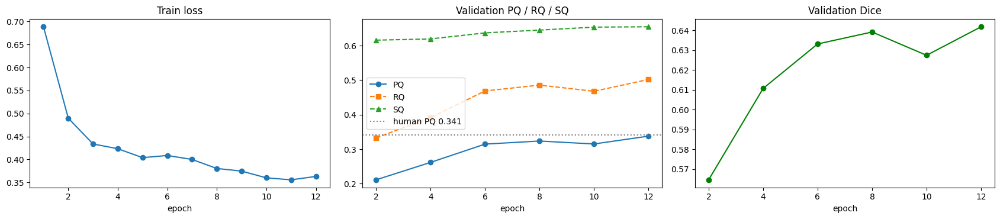

,train_loss,lr_dec,train_s,PQ (mean/record),PQ (pooled),SQ,RQ,Dice,val_s
epoch,,,,,,,,,
1,0.6885,0.0009,114.2701,NaN,NaN,NaN,NaN,NaN,NaN
2,0.4899,0.0010,113.5841,0.2115,0.2095,0.6158,0.3329,0.5645,94.3068
3,0.4337,0.0009,113.1911,NaN,NaN,NaN,NaN,NaN,NaN
4,0.4235,0.0008,112.9002,0.2619,0.2627,0.6193,0.3917,0.6106,80.5304
5,0.4040,0.0007,112.6837,NaN,NaN,NaN,NaN,NaN,NaN
6,0.4088,0.0006,112.6732,0.3149,0.3178,0.6369,0.4688,0.6331,67.4220
7,0.4001,0.0004,112.8279,NaN,NaN,NaN,NaN,NaN,NaN
8,0.3805,0.0003,112.5602,0.3237,0.3261,0.6449,0.4857,0.6391,69.8667
9,0.3748,0.0002,112.7571,NaN,NaN,NaN,NaN,NaN,NaN



Done in 30.3 min | best epoch 12 | best PQ 0.3379 (human ceiling 0.341)

=== Best epoch: overall ===


,PQ (mean/record),PQ (pooled),SQ,RQ,Dice
0,0.3379,0.3367,0.6545,0.5021,0.6417


=== Best epoch: by instrument ===


,records,PQ,SQ,RQ,Dice
instrument,,,,,
Bh,40,0.307,0.655,0.454,0.626
Ch,42,0.347,0.632,0.524,0.644
Lh,32,0.332,0.647,0.497,0.635
Mh,35,0.329,0.649,0.492,0.627
Th,41,0.325,0.674,0.484,0.641
Uh,44,0.380,0.667,0.554,0.671


=== Instance counts (sum over records) ===


,TP,FP,FN,GT filaments,Pred x records
0,1137,1786,477,1614,2923


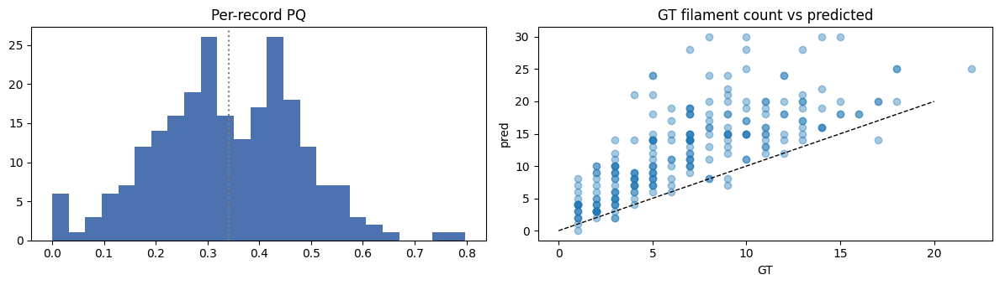

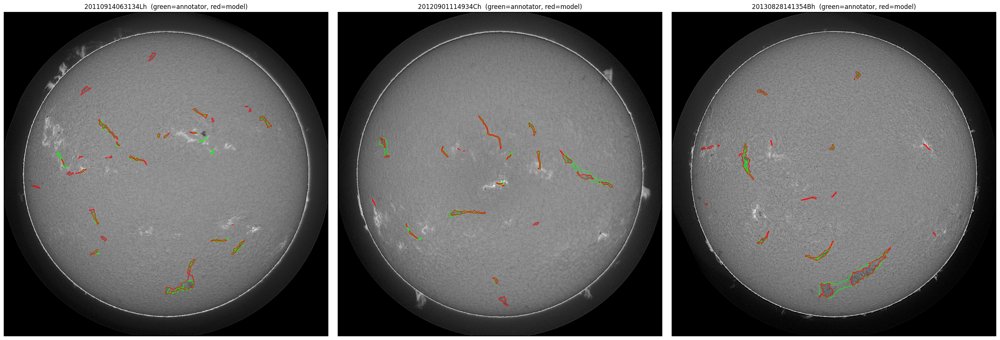

In [33]:
from IPython.display import clear_output

# ---------------- Config ----------------
TAG = f"fold{FOLD}"
EPOCHS, EVAL_EVERY = 12, 2
THR, MIN_AREA, CEIL_PQ = 0.5, 50, 0.341
va_list = [int(i) for i in va_idx]

def make_model():
    m, src = build_model(ENCODER, pretrained=True)
    m.segmentation_head[0].bias.data.fill_(-4.0)
    return m.to(dev).to(memory_format=torch.channels_last), src

# ---------------- Inference + instance extraction ----------------
@torch.no_grad()
def predict_probs(model, idx_list, bs=2):
    model.eval()
    out = np.zeros((len(idx_list), H, W), np.uint8)
    for s in range(0, len(idx_list), bs):
        ii = idx_list[s:s + bs]
        x = torch.from_numpy((np.stack([X[i] for i in ii]).astype(np.float32) - MEAN) / STD)[:, None].to(dev)
        with torch.autocast("cuda", dtype=torch.float16):
            p = torch.sigmoid(model(x.contiguous(memory_format=torch.channels_last)).float())
        out[s:s + len(ii)] = (p[:, 0] * 255).round().byte().cpu().numpy()
    return out

def prob_to_rles(p8, thr=THR, min_area=MIN_AREA):
    m = (p8 > int(thr * 255)).astype(np.uint8)
    n, lab, stats, _ = cv2.connectedComponentsWithStats(m, connectivity=8)
    rles = []
    for k in range(1, n):
        if stats[k, cv2.CC_STAT_AREA] < min_area:
            continue
        x0, y0, w, h = stats[k, :4]
        full = np.zeros((H, W), np.uint8)
        full[y0:y0 + h, x0:x0 + w] = (lab[y0:y0 + h, x0:x0 + w] == k)
        rles.append(mu.encode(np.asfortranarray(full)))
    return rles

def evaluate(probs, idx_list, thr=THR, min_area=MIN_AREA):
    rows = []
    for j, i in enumerate(idx_list):
        pr = prob_to_rles(probs[j], thr, min_area)
        pm = probs[j] > int(thr * 255)
        for rec in stem_df.loc[i, "records"]:
            gt = rle_by_rec[rec]
            m = pq_rles(gt, pr)
            g = mu.decode(mu.merge(gt)).astype(bool)
            m.update(dice=2 * (pm & g).sum() / max(pm.sum() + g.sum(), 1),
                     n_pred=len(pr), n_gt=len(gt),
                     instrument=stem_df.loc[i, "instrument"], stem=stem_df.loc[i, "stem"])
            rows.append(m)
    return pd.DataFrame(rows)

def summarize(df):
    return {"PQ (mean/record)": df["pq"].mean(), "PQ (pooled)": pooled_pq(df),
            "SQ": df["sq"].mean(), "RQ": df["rq"].mean(), "Dice": df["dice"].mean()}

# ---------------- Model / optimizer ----------------
gc.collect(); torch.cuda.empty_cache()
model, wsrc = make_model()
enc_params = list(model.encoder.parameters()); enc_ids = {id(p) for p in enc_params}
dec_params = [p for p in model.parameters() if id(p) not in enc_ids]
opt = torch.optim.AdamW([{"params": enc_params, "lr": 3e-4}, {"params": dec_params, "lr": 1e-3}], weight_decay=1e-4)
spe = len(train_dl); total = EPOCHS * spe
sched = torch.optim.lr_scheduler.OneCycleLR(opt, max_lr=[3e-4, 1e-3], total_steps=total, pct_start=0.1)
scaler = torch.amp.GradScaler("cuda")
print(f"{TAG} | Unet/{ENCODER} ({wsrc}) | {EPOCHS} epochs x {spe} steps | train {len(tr_idx)} imgs, val {len(va_idx)} imgs")

hist, best = [], {"pq": -1, "epoch": -1}
best_probs, best_df = None, None
t_start = time.time()

def show_progress():
    clear_output(wait=True)
    h = pd.DataFrame(hist)
    has_ev = "PQ (mean/record)" in h.columns
    ev = h.dropna(subset=["PQ (mean/record)"]) if has_ev else h.iloc[0:0]
    fig, ax = plt.subplots(1, 3, figsize=(17, 3.8))
    ax[0].plot(h["epoch"], h["train_loss"], "o-"); ax[0].set_title("Train loss")
    if len(ev):
        ax[1].plot(ev["epoch"], ev["PQ (mean/record)"], "o-", label="PQ")
        ax[1].plot(ev["epoch"], ev["RQ"], "s--", label="RQ")
        ax[1].plot(ev["epoch"], ev["SQ"], "^--", label="SQ")
        ax[1].axhline(CEIL_PQ, color="gray", ls=":", label="human PQ 0.341"); ax[1].legend()
        ax[2].plot(ev["epoch"], ev["Dice"], "o-", color="green")
    ax[1].set_title("Validation PQ / RQ / SQ"); ax[2].set_title("Validation Dice")
    for a in ax: a.set_xlabel("epoch")
    plt.tight_layout(); plt.show()
    display(h.round(4).set_index("epoch"))

# ---------------- Train ----------------
try:
    for ep in range(1, EPOCHS + 1):
        model.train(); t0 = time.time(); run = 0.0
        for xb_t, yb_t in train_dl:
            xb_t = xb_t.to(dev, non_blocking=True).contiguous(memory_format=torch.channels_last)
            yb_t = yb_t.to(dev, non_blocking=True)
            with torch.autocast("cuda", dtype=torch.float16):
                logits = model(xb_t)
            loss = seg_loss(logits, yb_t)[0]
            opt.zero_grad(set_to_none=True)
            scaler.scale(loss).backward()
            scaler.unscale_(opt); torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(opt); scaler.update(); sched.step()
            run += loss.item()
        row = {"epoch": ep, "train_loss": run / spe, "lr_dec": opt.param_groups[1]["lr"], "train_s": time.time() - t0}
        if ep % EVAL_EVERY == 0 or ep == EPOCHS:
            torch.cuda.empty_cache(); t1 = time.time()
            probs = predict_probs(model, va_list); df = evaluate(probs, va_list)
            row.update(summarize(df)); row["val_s"] = time.time() - t1
            if row["PQ (mean/record)"] > best["pq"]:
                best = {"pq": row["PQ (mean/record)"], "epoch": ep}
                best_probs, best_df = probs, df
                torch.save({"model": model.state_dict(), "epoch": ep, "pq": best["pq"]}, f"{WORK}/ckpt/{TAG}_best.pt")
        torch.save({"model": model.state_dict(), "epoch": ep}, f"{WORK}/ckpt/{TAG}_last.pt")
        hist.append(row); show_progress()
except KeyboardInterrupt:
    print("Interrupted: keeping best checkpoint so far.")

# ---------------- Summary ----------------
if best_df is None:
    print("No validation was completed, so there is nothing to summarize.")
else:
    print(f"\nDone in {(time.time() - t_start) / 60:.1f} min | best epoch {best['epoch']} | "
          f"best PQ {best['pq']:.4f} (human ceiling {CEIL_PQ})")
    np.save(f"{CACHE}/val_probs_{TAG}.npy", best_probs)

    print("\n=== Best epoch: overall ===")
    display(pd.DataFrame([summarize(best_df)]).round(4))
    print("=== Best epoch: by instrument ===")
    display(best_df.groupby("instrument").agg(records=("pq", "size"), PQ=("pq", "mean"), SQ=("sq", "mean"),
                                              RQ=("rq", "mean"), Dice=("dice", "mean")).round(3))
    print("=== Instance counts (sum over records) ===")
    display(pd.DataFrame({"TP": [best_df["tp"].sum()], "FP": [best_df["fp"].sum()], "FN": [best_df["fn"].sum()],
                          "GT filaments": [best_df["n_gt"].sum()], "Pred x records": [best_df["n_pred"].sum()]}))

    fig, ax = plt.subplots(1, 2, figsize=(12, 3.5))
    ax[0].hist(best_df["pq"], bins=25, color="#4c72b0"); ax[0].axvline(CEIL_PQ, color="gray", ls=":")
    ax[0].set_title("Per-record PQ")
    ax[1].scatter(best_df["n_gt"], best_df["n_pred"], alpha=.4); ax[1].plot([0, 20], [0, 20], "k--", lw=1)
    ax[1].set_title("GT filament count vs predicted"); ax[1].set_xlabel("GT"); ax[1].set_ylabel("pred")
    plt.tight_layout(); plt.show()

    # ---- Visual: annotator (green) vs model (red) on validation frames ----
    order = np.argsort([-stem_df.loc[i, "n_fil"] for i in va_list])[[0, 20, 60]]
    fig, axes = plt.subplots(1, 3, figsize=(27, 9))
    for ax_, j in zip(axes, order):
        i = va_list[j]; rec = stem_df.loc[i, "records"][0]
        g = cv2.resize(mu.decode(mu.merge(rle_by_rec[rec])), (1024, 1024), interpolation=cv2.INTER_NEAREST)
        p = cv2.resize((best_probs[j] > int(THR * 255)).astype(np.uint8), (1024, 1024), interpolation=cv2.INTER_NEAREST)
        ax_.imshow(X[i][::2, ::2], cmap="gray")
        for m_, c in [(g, "lime"), (p, "red")]:
            for cnt in cv2.findContours(m_, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)[0]:
                ax_.plot(cnt[:, 0, 0], cnt[:, 0, 1], color=c, lw=1)
        ax_.set_title(f"{stem_df.loc[i, 'stem']}  (green=annotator, red=model)"); ax_.axis("off")
    plt.tight_layout(); plt.savefig(f"{WORK}/figs/val_predictions_{TAG}.png", dpi=60); plt.show()

## 7. Post-processing tuning (fold 0 validation)
Baseline (Cell 6): threshold 0.5, minimum area 50 px. PQ is limited by false positives, so we tune three levers on the cached validation probability maps:
- **Hysteresis:** low threshold sets the extent of a component, and the component is kept only if its peak probability exceeds a high threshold
- **Minimum component area** (px)
- **Morphological closing** (ellipse diameter, px) to merge fragments of one filament before labeling

The search is staged (hysteresis, then area, then closing) to keep runtime manageable. Reported: PQ/SQ/RQ and TP/FP/FN for every setting, baseline vs tuned, per-instrument results, and an overlay comparison.
Caveat: tuned on 144 images from one fold; final settings will be re-tuned on out-of-fold predictions from all folds.

Baseline PQ = 0.3379  (Cell 6 reported 0.3379)

A {'low': 0.3, 'high': 0.5} -> PQ 0.3447 | RQ 0.513 | FP 1643 | 61s
A {'low': 0.3, 'high': 0.6} -> PQ 0.3447 | RQ 0.513 | FP 1643 | 61s
A {'low': 0.3, 'high': 0.7} -> PQ 0.3447 | RQ 0.513 | FP 1641 | 61s
A {'low': 0.3, 'high': 0.8} -> PQ 0.3456 | RQ 0.515 | FP 1640 | 61s
A {'low': 0.4, 'high': 0.5} -> PQ 0.3458 | RQ 0.514 | FP 1642 | 61s
A {'low': 0.4, 'high': 0.6} -> PQ 0.3458 | RQ 0.514 | FP 1642 | 61s
A {'low': 0.4, 'high': 0.7} -> PQ 0.3458 | RQ 0.514 | FP 1642 | 56s
A {'low': 0.4, 'high': 0.8} -> PQ 0.3467 | RQ 0.516 | FP 1641 | 61s
A {'low': 0.5, 'high': 0.5} -> PQ 0.3475 | RQ 0.516 | FP 1633 | 62s
A {'low': 0.5, 'high': 0.6} -> PQ 0.3475 | RQ 0.516 | FP 1633 | 61s
A {'low': 0.5, 'high': 0.7} -> PQ 0.3475 | RQ 0.516 | FP 1633 | 61s
A {'low': 0.5, 'high': 0.8} -> PQ 0.3475 | RQ 0.516 | FP 1633 | 61s

=== Stage A: hysteresis (min_area=100, no closing) ===


,min_area,close,low,high,PQ,PQ_pooled,SQ,RQ,TP,FP,FN,pred/GT
0,100,0,0.5,0.5,0.3475,0.3482,0.6545,0.5163,1136,1633,478,1.7156
1,100,0,0.5,0.6,0.3475,0.3482,0.6545,0.5163,1136,1633,478,1.7156
2,100,0,0.5,0.7,0.3475,0.3482,0.6545,0.5163,1136,1633,478,1.7156
3,100,0,0.5,0.8,0.3475,0.3482,0.6545,0.5163,1136,1633,478,1.7156
4,100,0,0.4,0.8,0.3467,0.3478,0.6542,0.5156,1139,1641,475,1.7224
5,100,0,0.4,0.7,0.3458,0.3477,0.6542,0.5142,1139,1642,475,1.7230
6,100,0,0.4,0.5,0.3458,0.3477,0.6542,0.5142,1139,1642,475,1.7230
7,100,0,0.4,0.6,0.3458,0.3477,0.6542,0.5142,1139,1642,475,1.7230
8,100,0,0.3,0.8,0.3456,0.3477,0.6529,0.5146,1139,1640,475,1.7218
9,100,0,0.3,0.7,0.3447,0.3476,0.6529,0.5132,1139,1641,475,1.7224


B {'min_area': 50} -> PQ 0.3379 | RQ 0.502 | FP 1786 | 63s
B {'min_area': 100} -> PQ 0.3475 | RQ 0.516 | FP 1633 | 61s
B {'min_area': 200} -> PQ 0.3621 | RQ 0.538 | FP 1444 | 58s
B {'min_area': 400} -> PQ 0.3848 | RQ 0.571 | FP 996 | 52s
B {'min_area': 800} -> PQ 0.3608 | RQ 0.532 | FP 538 | 42s

=== Stage B: minimum area ===


,low,high,close,min_area,PQ,PQ_pooled,SQ,RQ,TP,FP,FN,pred/GT
0,0.5,0.5,0,400,0.3848,0.3833,0.6520,0.5709,1038,996,576,1.2602
1,0.5,0.5,0,200,0.3621,0.3633,0.6547,0.5382,1133,1444,481,1.5967
2,0.5,0.5,0,800,0.3608,0.3607,0.6391,0.5322,779,538,835,0.8160
3,0.5,0.5,0,100,0.3475,0.3482,0.6545,0.5163,1136,1633,478,1.7156
4,0.5,0.5,0,50,0.3379,0.3367,0.6545,0.5021,1137,1786,477,1.8110


C {'close': 0} -> PQ 0.3848 | RQ 0.571 | FP 996 | 52s
C {'close': 5} -> PQ 0.3877 | RQ 0.576 | FP 983 | 51s
C {'close': 9} -> PQ 0.3902 | RQ 0.580 | FP 978 | 52s
C {'close': 15} -> PQ 0.3874 | RQ 0.577 | FP 975 | 54s
C {'close': 25} -> PQ 0.3834 | RQ 0.573 | FP 973 | 59s

=== Stage C: morphological closing ===


,low,high,min_area,close,PQ,PQ_pooled,SQ,RQ,TP,FP,FN,pred/GT
0,0.5,0.5,400,9,0.3902,0.3877,0.6511,0.5803,1051,978,563,1.2571
1,0.5,0.5,400,5,0.3877,0.3862,0.6520,0.5755,1045,983,569,1.2565
2,0.5,0.5,400,15,0.3874,0.3854,0.6501,0.5769,1043,975,571,1.2503
3,0.5,0.5,400,0,0.3848,0.3833,0.6520,0.5709,1038,996,576,1.2602
4,0.5,0.5,400,25,0.3834,0.3801,0.6477,0.5734,1028,973,586,1.2398



Best post-processing: {'low': 0.5, 'high': 0.5, 'min_area': 400, 'close': 9}


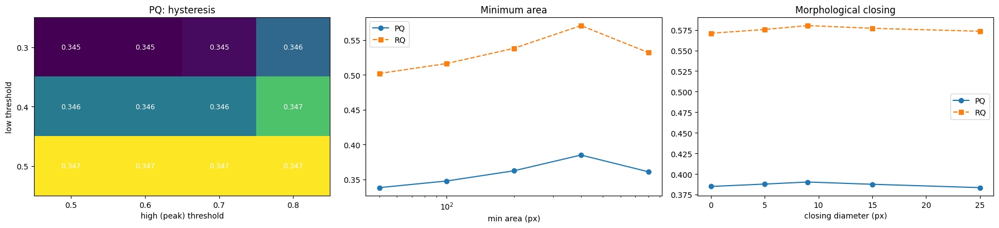


=== Baseline vs tuned (fold 0 validation) ===


,PQ,PQ_pooled,SQ,RQ,TP,FP,FN,pred/GT
baseline,0.3379,0.3367,0.6545,0.5021,1137.0,1786.0,477.0,1.8110
tuned,0.3902,0.3877,0.6511,0.5803,1051.0,978.0,563.0,1.2571


=== Tuned: by instrument ===


,records,PQ,SQ,RQ
instrument,,,,
Bh,40,0.354,0.639,0.523
Ch,42,0.366,0.632,0.551
Lh,32,0.385,0.650,0.574
Mh,35,0.395,0.649,0.590
Th,41,0.391,0.670,0.585
Uh,44,0.445,0.665,0.652


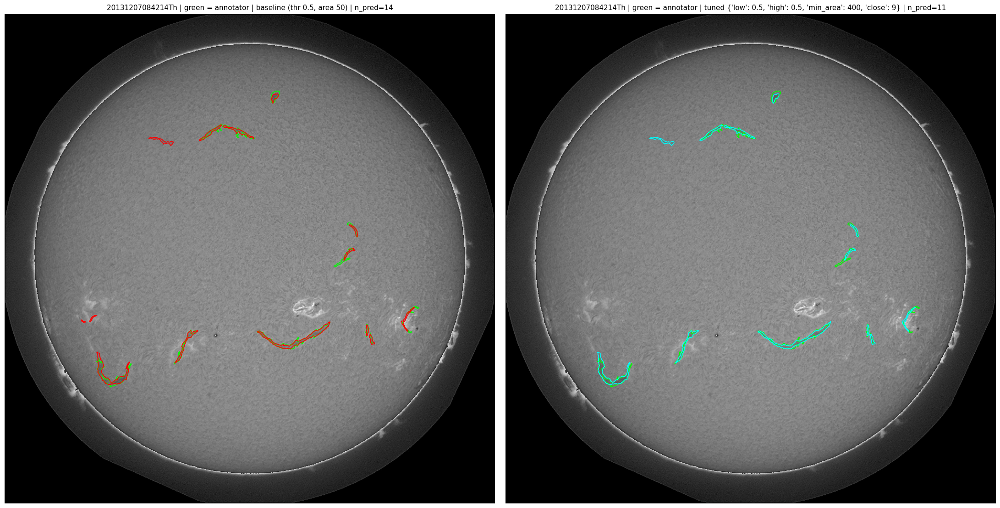

In [34]:
from scipy import ndimage as ndi

vp = best_probs if best_probs is not None else np.load(f"{CACHE}/val_probs_{TAG}.npy")

def pp_rles(p8, low=0.5, high=0.5, min_area=50, close=0):
    m = (p8 > int(low * 255)).astype(np.uint8)
    if close > 0:
        m = cv2.morphologyEx(m, cv2.MORPH_CLOSE, cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (close, close)))
    n, lab, stats, _ = cv2.connectedComponentsWithStats(m, connectivity=8)
    if n <= 1:
        return []
    peak = ndi.maximum(p8, labels=lab, index=np.arange(1, n))
    hi = int(high * 255)
    rles = []
    for k in range(1, n):
        if stats[k, cv2.CC_STAT_AREA] < min_area or peak[k - 1] <= hi:
            continue
        x0, y0, w, h = stats[k, :4]
        full = np.zeros((H, W), np.uint8)
        full[y0:y0 + h, x0:x0 + w] = (lab[y0:y0 + h, x0:x0 + w] == k)
        rles.append(mu.encode(np.asfortranarray(full)))
    return rles

def score_pp(probs, idx_list, **pp):
    rows = []
    for j, i in enumerate(idx_list):
        pr = pp_rles(probs[j], **pp)
        for rec in stem_df.loc[i, "records"]:
            m = pq_rles(rle_by_rec[rec], pr)
            m.update(n_pred=len(pr), n_gt=len(rle_by_rec[rec]), instrument=stem_df.loc[i, "instrument"])
            rows.append(m)
    return pd.DataFrame(rows)

def pp_summary(df):
    return {"PQ": df["pq"].mean(), "PQ_pooled": pooled_pq(df), "SQ": df["sq"].mean(), "RQ": df["rq"].mean(),
            "TP": int(df["tp"].sum()), "FP": int(df["fp"].sum()), "FN": int(df["fn"].sum()),
            "pred/GT": df["n_pred"].sum() / df["n_gt"].sum()}

def sweep(configs, base, label):
    rows = []
    for c in configs:
        t0 = time.time(); cfg = {**base, **c}
        s = pp_summary(score_pp(vp, va_list, **cfg))
        rows.append({**cfg, **s})
        print(f"{label} {c} -> PQ {s['PQ']:.4f} | RQ {s['RQ']:.3f} | FP {s['FP']} | {time.time() - t0:.0f}s")
    return pd.DataFrame(rows).sort_values("PQ", ascending=False).reset_index(drop=True)

# ---------- Baseline sanity check (should reproduce Cell 6: PQ 0.3379) ----------
BASE = dict(low=0.5, high=0.5, min_area=50, close=0)
base_df = score_pp(vp, va_list, **BASE)
print(f"Baseline PQ = {base_df['pq'].mean():.4f}  (Cell 6 reported {best['pq']:.4f})\n")

# ---------- Stage A: hysteresis ----------
cfgA = [dict(low=l, high=h) for l in [0.3, 0.4, 0.5] for h in [0.5, 0.6, 0.7, 0.8]]
A = sweep(cfgA, dict(min_area=100, close=0), "A")
print("\n=== Stage A: hysteresis (min_area=100, no closing) ===")
display(A.round(4))
bestA = A.iloc[0][["low", "high"]].to_dict()

# ---------- Stage B: minimum area ----------
B = sweep([dict(min_area=a) for a in [50, 100, 200, 400, 800]], dict(**bestA, close=0), "B")
print("\n=== Stage B: minimum area ===")
display(B.round(4))
bestB = int(B.iloc[0]["min_area"])

# ---------- Stage C: closing ----------
C = sweep([dict(close=c) for c in [0, 5, 9, 15, 25]], dict(**bestA, min_area=bestB), "C")
print("\n=== Stage C: morphological closing ===")
display(C.round(4))
PP = dict(low=float(bestA["low"]), high=float(bestA["high"]), min_area=bestB, close=int(C.iloc[0]["close"]))
print("\nBest post-processing:", PP)

# ---------- Plots ----------
fig, ax = plt.subplots(1, 3, figsize=(18, 4.2))
pv = A.pivot_table(index="low", columns="high", values="PQ")
im = ax[0].imshow(pv.values, cmap="viridis", aspect="auto")
ax[0].set_xticks(range(len(pv.columns))); ax[0].set_xticklabels(pv.columns)
ax[0].set_yticks(range(len(pv.index))); ax[0].set_yticklabels(pv.index)
for r in range(pv.shape[0]):
    for c in range(pv.shape[1]):
        ax[0].text(c, r, f"{pv.values[r, c]:.3f}", ha="center", va="center", color="w", fontsize=9)
ax[0].set_xlabel("high (peak) threshold"); ax[0].set_ylabel("low threshold"); ax[0].set_title("PQ: hysteresis")
Bs = B.sort_values("min_area"); ax[1].plot(Bs["min_area"], Bs["PQ"], "o-", label="PQ"); ax[1].plot(Bs["min_area"], Bs["RQ"], "s--", label="RQ")
ax[1].set_xscale("log"); ax[1].set_xlabel("min area (px)"); ax[1].legend(); ax[1].set_title("Minimum area")
Cs = C.sort_values("close"); ax[2].plot(Cs["close"], Cs["PQ"], "o-", label="PQ"); ax[2].plot(Cs["close"], Cs["RQ"], "s--", label="RQ")
ax[2].set_xlabel("closing diameter (px)"); ax[2].legend(); ax[2].set_title("Morphological closing")
plt.tight_layout(); plt.savefig(f"{WORK}/figs/pp_tuning_{TAG}.png", dpi=90); plt.show()

# ---------- Baseline vs tuned ----------
tuned_df = score_pp(vp, va_list, **PP)
cmp_ = pd.DataFrame({"baseline": pp_summary(base_df), "tuned": pp_summary(tuned_df)}).T
print("\n=== Baseline vs tuned (fold 0 validation) ===")
display(cmp_.round(4))
print("=== Tuned: by instrument ===")
display(tuned_df.groupby("instrument").agg(records=("pq", "size"), PQ=("pq", "mean"),
                                           SQ=("sq", "mean"), RQ=("rq", "mean")).round(3))
import json
json.dump(PP, open(f"{WORK}/ckpt/pp_{TAG}.json", "w"))

# ---------- Overlay: annotator (green) vs baseline (red) vs tuned (cyan) ----------
j = int(np.argsort([-stem_df.loc[i, "n_fil"] for i in va_list])[30]); i = va_list[j]
rec = stem_df.loc[i, "records"][0]
def contours(rles):
    out = []
    for r in rles:
        m = cv2.resize(mu.decode(r), (1024, 1024), interpolation=cv2.INTER_NEAREST)
        out += cv2.findContours(m, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)[0]
    return out
fig, axes = plt.subplots(1, 2, figsize=(22, 11))
for ax_, (name, rl, col) in zip(axes, [("baseline (thr 0.5, area 50)", pp_rles(vp[j], **BASE), "red"),
                                       (f"tuned {PP}", pp_rles(vp[j], **PP), "cyan")]):
    ax_.imshow(X[i][::2, ::2], cmap="gray")
    for cnt in contours(rle_by_rec[rec]):
        ax_.plot(cnt[:, 0, 0], cnt[:, 0, 1], color="lime", lw=1.2)
    for cnt in contours(rl):
        ax_.plot(cnt[:, 0, 0], cnt[:, 0, 1], color=col, lw=1.2)
    ax_.set_title(f"{stem_df.loc[i, 'stem']} | green = annotator | {name} | n_pred={len(rl)}", fontsize=11); ax_.axis("off")
plt.tight_layout(); plt.savefig(f"{WORK}/figs/pp_overlay_{TAG}.png", dpi=60); plt.show()

In [35]:
import zipfile, glob, shutil, time, json, os

STAMP = time.strftime("%Y%m%d_%H%M")
PKG = f"solar_filament_run_{STAMP}"
STAGE = f"{CACHE}/{PKG}"
INCLUDE_CKPT = True            # checkpoints are ~100 MB each; set False for a small zip
shutil.rmtree(STAGE, ignore_errors=True)
for d in ["tables", "figures", "config"]:
    os.makedirs(f"{STAGE}/{d}", exist_ok=True)
for old in glob.glob(f"{WORK}/solar_filament_run_*.zip"):   # avoid piling up old zips in output
    os.remove(old)

# ---------------- Tables -> CSV ----------------
tables = []
def T(name, fn, desc, index=True):
    try:
        obj = fn()
        df = obj if isinstance(obj, pd.DataFrame) else pd.DataFrame(obj)
        df.to_csv(f"{STAGE}/tables/{name}.csv", index=index)
        tables.append((name, desc))
    except Exception as e:
        print(f"  skipped table {name}: {type(e).__name__}")

T("01_environment", lambda: pd.DataFrame(env.items(), columns=["item", "value"]), "Python/PyTorch/GPU environment", False)
T("02_dataset_paths", lambda: paths, "Data locations and train/test image counts", False)
T("03_annotation_geometry", lambda: ann_df[["area", "bw", "bh", "bbox_aspect", "bbox_fill"]].describe(percentiles=[.05, .25, .5, .75, .95]).round(2), "Filament area and bounding-box statistics (8,199 polygons)")
T("04_category_counts", lambda: ann_df["cat"].value_counts().to_frame("count"), "Annotation category counts")
T("05_annotators_per_image", lambda: img_df.groupby("stem")["annotator"].nunique().value_counts().sort_index().rename("n_images").to_frame(), "Images by number of annotators (1, 2 or 3)")
T("06_fold_assignment", lambda: stem_df[["stem", "date", "instrument", "n_ann", "fold"]], "Image-to-fold map (5 folds grouped by observation date)", False)
T("07_fold_summary", lambda: fold_tbl, "Images, dates and instruments per fold")
T("08_label_agreement", lambda: lab.groupby("n_ann").agg(images=("n_ann", "size"), fg_pct=("fg_any_pct", "mean"), frac_pixels_all_agree=("pixel_agreement", "mean")).round(3), "Foreground rate and pixel agreement by number of annotators")
T("09_instrument_intensity", lambda: bright, "Image intensity statistics by GONG site")
T("10_human_ceiling_by_instrument", lambda: ceil.groupby("instrument").agg(pairs=("pq", "size"), PQ=("pq", "mean"), SQ=("sq", "mean"), RQ=("rq", "mean")).round(3), "Annotator-vs-annotator PQ by site (human ceiling)")
T("11_human_ceiling_pairs", lambda: ceil, "Annotator-vs-annotator PQ for every pair (598 pairs)", False)
T("12_crop_foreground_stats", lambda: stats, "Foreground share of training crops, biased vs uniform sampling")
T("13_training_history_fold0", lambda: pd.DataFrame(hist), "Epoch-by-epoch loss and validation PQ/SQ/RQ/Dice", False)
T("14_validation_per_record_baseline", lambda: best_df, "Per-record validation metrics, baseline post-processing", False)
T("15_validation_by_instrument_baseline", lambda: best_df.groupby("instrument").agg(records=("pq", "size"), PQ=("pq", "mean"), SQ=("sq", "mean"), RQ=("rq", "mean"), Dice=("dice", "mean")).round(3), "Validation metrics by site, baseline post-processing")
T("16_postproc_A_hysteresis", lambda: A, "Post-processing sweep A: hysteresis thresholds", False)
T("17_postproc_B_min_area", lambda: B, "Post-processing sweep B: minimum component area", False)
T("18_postproc_C_closing", lambda: C, "Post-processing sweep C: morphological closing", False)
T("19_baseline_vs_tuned", lambda: cmp_, "Baseline vs tuned post-processing (fold 0 validation)")
T("20_tuned_by_instrument", lambda: tuned_df.groupby("instrument").agg(records=("pq", "size"), PQ=("pq", "mean"), SQ=("sq", "mean"), RQ=("rq", "mean")).round(3), "Validation metrics by site, tuned post-processing")
T("21_tta_comparison", lambda: cmp_tta, "Single pass vs flip TTA (fold 0 validation)")
T("22_submission_checks", lambda: pd.DataFrame(chk.items(), columns=["check", "value"]), "Submission file format checks", False)
T("23_test_predictions_per_image", lambda: pi, "Predicted filament count per test image", False)

# ---------------- Training-curve figure (regenerated from history) ----------------
try:
    h_ = pd.DataFrame(hist); ev_ = h_.dropna(subset=["PQ (mean/record)"])
    fig, ax = plt.subplots(1, 3, figsize=(17, 3.8))
    ax[0].plot(h_["epoch"], h_["train_loss"], "o-"); ax[0].set_title("Train loss")
    ax[1].plot(ev_["epoch"], ev_["PQ (mean/record)"], "o-", label="PQ"); ax[1].plot(ev_["epoch"], ev_["RQ"], "s--", label="RQ")
    ax[1].plot(ev_["epoch"], ev_["SQ"], "^--", label="SQ"); ax[1].axhline(0.341, color="gray", ls=":", label="human PQ 0.341")
    ax[1].legend(); ax[1].set_title("Validation PQ / RQ / SQ")
    ax[2].plot(ev_["epoch"], ev_["Dice"], "o-", color="green"); ax[2].set_title("Validation Dice")
    for a in ax: a.set_xlabel("epoch")
    plt.tight_layout(); plt.savefig(f"{WORK}/figs/training_curves_fold0.png", dpi=110); plt.close(fig)
except Exception as e:
    print("  skipped training curves:", type(e).__name__)

# ---------------- Figures: copy with numbered, descriptive names ----------------
FIGS = [
 ("audit_stats.png", "Annotation audit: filaments per record, area, aspect, bbox, fill and records per year"),
 ("gt_overlays.png", "Ground-truth polygon overlays on six random training images"),
 ("instruments.png", "One example image from each of the six GONG sites"),
 ("consensus.png", "Same image: three annotators and the soft consensus target"),
 ("train_batch.png", "Training batch: 768 px crops with soft consensus targets"),
 ("overfit_check.png", "Single-batch overfit sanity test of the model and loss"),
 ("training_curves_fold0.png", "Fold 0 training loss and validation PQ/SQ/RQ/Dice vs the human PQ line"),
 ("val_predictions_fold0.png", "Fold 0 validation: annotator (green) vs model (red)"),
 ("pp_tuning_fold0.png", "Post-processing sweeps: hysteresis heatmap, minimum area, closing"),
 ("pp_overlay_fold0.png", "Annotator (green) vs baseline and tuned post-processing"),
 ("test_predictions_baseline.png", "Baseline test-set predictions (cyan contours)"),
]
figs_saved = []
for n, (src, cap) in enumerate(FIGS, 1):
    p = f"{WORK}/figs/{src}"
    if os.path.exists(p):
        new = f"{n:02d}_{src}"
        shutil.copy(p, f"{STAGE}/figures/{new}"); figs_saved.append((new, cap))
known = {s for s, _ in FIGS}
for p in sorted(glob.glob(f"{WORK}/figs/*.png")):
    if os.path.basename(p) not in known:
        shutil.copy(p, f"{STAGE}/figures/extra_{os.path.basename(p)}"); figs_saved.append((f"extra_{os.path.basename(p)}", "Additional figure"))

# ---------------- Config + requirements ----------------
G = globals()
cfg = {k: G.get(k) for k in ["ENCODER", "FOLD", "CROP", "EPOCHS", "EVAL_EVERY", "MEAN", "STD", "SEED", "THR", "MIN_AREA", "USE_TTA"]}
cfg["post_processing"] = G.get("PP"); cfg["pretrained_weights"] = "imagenet (training only; inference loads checkpoints)"
json.dump(cfg, open(f"{STAGE}/config/config.json", "w"), indent=2, default=str)
if os.path.exists(f"{WORK}/requirements.txt"):
    shutil.copy(f"{WORK}/requirements.txt", f"{STAGE}/config/requirements.txt")

# ---------------- README ----------------
res = []
try: res.append(f"- Fold {FOLD} validation (144 images), baseline post-processing (threshold 0.5, min area 50 px): PQ {best['pq']:.4f} at epoch {best['epoch']}")
except Exception: pass
try:
    t = cmp_.loc["tuned"]
    res.append(f"- Tuned post-processing {PP}: PQ {t['PQ']:.4f}, SQ {t['SQ']:.4f}, RQ {t['RQ']:.4f}; TP/FP/FN {int(t['TP'])}/{int(t['FP'])}/{int(t['FN'])}")
except Exception: pass
try: res.append(f"- Human annotator-vs-annotator PQ ceiling: {ceil['pq'].mean():.3f} ({len(ceil)} pairs)")
except Exception: pass

readme = f"""# Solar Filament Segmentation Challenge 2026 - run package ({STAMP})

Kaggle competition on automatic segmentation of solar filaments in GONG H-Alpha images (MAGFiLO ground truth).
Primary metric: Panoptic Quality (PQ); also Dice/IoU and fragmentation/merging penalties.

## Results so far
{chr(10).join(res) if res else "- (no results available when this package was built)"}
- Caveat: post-processing was tuned on the same 144 validation images it is scored on, so these numbers are optimistic.
  Fold-0 only; five-fold out-of-fold results will replace them.

## Method (current baseline)
- Data: 707 training images (2048x2048, 8-bit), 1,154 annotation records, 8,199 polygons. Some images have 2-3 annotators.
- Targets: soft consensus mask (mean of annotator masks) per image.
- Split: 5 folds grouped by observation date and stratified by instrument (no date leakage).
- Model: U-Net with ResNet34 encoder (ImageNet init), 1 input channel, BCE + soft Dice loss, fp16, AdamW + OneCycle.
- Training crops: 768 px at random scale, 60% centred on foreground, flips/rot90/brightness/gamma/blur/noise.
- Post-processing: threshold, morphological closing, connected components, minimum-area filter; PQ computed at IoU > 0.5.

## Folder layout
- `figures/` numbered figures (index below)
- `tables/` every table as CSV (index below)
- `models/` checkpoints (`fold0_best.pt` = best validation PQ, `fold0_last.pt`) and `pp_fold0.json` post-processing settings
- `submission/` `submission.csv` (filament_id, segmentation_rle as RLE counts only) if one was generated
- `config/` `config.json` (settings), `requirements.txt` (package versions)
- `MANIFEST.csv` every file with size
- `code/` place the notebook here (Kaggle: File > Download notebook)

## Figure index
{chr(10).join(f"- `{n}`: {c}" for n, c in figs_saved)}

## Table index
{chr(10).join(f"- `{n}.csv`: {d}" for n, d in tables)}

## Reproduce
1. Install `config/requirements.txt` (plus `segmentation-models-pytorch` as listed).
2. Run the notebook top to bottom on the competition data with a GPU.
3. Inference needs no internet: build `smp.Unet(encoder_weights=None)` and load a checkpoint from `models/`.
"""
open(f"{STAGE}/README.md", "w").write(readme)

# ---------------- Zip ----------------
zpath = f"{WORK}/{PKG}.zip"
with zipfile.ZipFile(zpath, "w", zipfile.ZIP_DEFLATED) as z:
    for root, _, files in os.walk(STAGE):
        for f in files:
            full = os.path.join(root, f)
            z.write(full, arcname=f"{PKG}/{os.path.relpath(full, STAGE)}")
    if INCLUDE_CKPT:
        for f in sorted(glob.glob(f"{WORK}/ckpt/*")):
            z.write(f, arcname=f"{PKG}/models/{os.path.basename(f)}")
    if os.path.exists(f"{WORK}/submission.csv"):
        z.write(f"{WORK}/submission.csv", arcname=f"{PKG}/submission/submission.csv")
    z.writestr(f"{PKG}/code/PUT_NOTEBOOK_HERE.txt", "Kaggle: File > Download notebook, then add the .ipynb to this folder.\n")

with zipfile.ZipFile(zpath) as z:
    man = pd.DataFrame([(i.filename.replace(PKG + "/", ""), round(i.file_size / 1e6, 2)) for i in z.infolist()], columns=["file", "MB"])
with zipfile.ZipFile(zpath, "a") as z:
    z.writestr(f"{PKG}/MANIFEST.csv", man.to_csv(index=False))

print(f"=== Package: {zpath}  ({os.path.getsize(zpath) / 1e6:.0f} MB) ===")
print(f"{len(figs_saved)} figures | {len(tables)} tables | checkpoints included: {INCLUDE_CKPT}")
display(man)
print(readme[:1500])

  skipped table 21_tta_comparison: NameError
  skipped table 22_submission_checks: NameError
  skipped table 23_test_predictions_per_image: NameError
=== Package: /kaggle/working/solar_filament_run_20261007_2018.zip  (186 MB) ===
10 figures | 20 tables | checkpoints included: True


,file,MB
0,README.md,0.00
1,config/config.json,0.00
2,config/requirements.txt,0.00
3,figures/10_pp_overlay_fold0.png,0.37
4,figures/06_overfit_check.png,0.52
5,figures/02_gt_overlays.png,1.20
6,figures/09_pp_tuning_fold0.png,0.05
7,figures/07_training_curves_fold0.png,0.07
8,figures/04_consensus.png,0.12
9,figures/08_val_predictions_fold0.png,0.69


# Solar Filament Segmentation Challenge 2026 - run package (20261007_2018)

Kaggle competition on automatic segmentation of solar filaments in GONG H-Alpha images (MAGFiLO ground truth).
Primary metric: Panoptic Quality (PQ); also Dice/IoU and fragmentation/merging penalties.

## Results so far
- Fold 0 validation (144 images), baseline post-processing (threshold 0.5, min area 50 px): PQ 0.3379 at epoch 12
- Tuned post-processing {'low': 0.5, 'high': 0.5, 'min_area': 400, 'close': 9}: PQ 0.3902, SQ 0.6511, RQ 0.5803; TP/FP/FN 1051/978/563
- Human annotator-vs-annotator PQ ceiling: 0.341 (598 pairs)
- Caveat: post-processing was tuned on the same 144 validation images it is scored on, so these numbers are optimistic.
  Fold-0 only; five-fold out-of-fold results will replace them.

## Method (current baseline)
- Data: 707 training images (2048x2048, 8-bit), 1,154 annotation records, 8,199 polygons. Some images have 2-3 annotators.
- Targets: soft consensus mask (mean of annotator masks) 

## 8. Baseline submission (fold-0 model + flip TTA + tuned post-processing)
- Load `fold0_best.pt` into a U-Net built **without** downloading weights (works with internet off)
- **Flip TTA** (identity, horizontal, vertical, both): checked on the validation fold first and used only if it beats a single pass
- Test inference at full 2048x2048 resolution with the tuned post-processing from Cell 7
- Every test image gets at least one row (fallback to its largest component if everything is filtered)
- Write `submission.csv` (`filament_id`, `segmentation_rle` = RLE counts only, no quotes) and validate it: unique ids, ids match test images, RLE round trip, file re-read from disk

Loaded 1 model(s) | post-processing: {'low': 0.5, 'high': 0.5, 'min_area': 400, 'close': 9}
TTA validation inference: 69s

=== Single pass vs flip TTA (fold 0 validation) ===


,PQ,PQ_pooled,SQ,RQ,TP,FP,FN,pred/GT
single pass,0.3902,0.3877,0.6511,0.5803,1051.0,978.0,563.0,1.2571
flip TTA,0.3886,0.3876,0.6498,0.5763,1030.0,937.0,584.0,1.2187


Using TTA: False

No sample_submission file found; using columns filament_id, segmentation_rle
Test inference: 180 images in 94s

=== Submission checks ===


,check,value
0,rows (filaments),1640
1,test images,180
2,images with >=1 row,178
3,images fallback-only,0
4,images with no prediction,2
5,unique ids,True
6,quotes in RLE,0
7,mean filaments / image,9.11
8,train GT mean / record,7.1
9,re-read rows match,True


NOTE: 2 test image(s) have no predicted filament and therefore no row.
RLE round-trip decodes to non-empty masks: True

=== Predicted filaments per image, by instrument ===


,count,mean,std,min,25%,50%,75%,max
instrument,,,,,,,,
Bh,33.0,10.27,5.11,1.0,6.00,10.0,14.00,23.0
Ch,33.0,9.24,4.94,0.0,5.00,10.0,13.00,18.0
Lh,34.0,8.88,4.93,2.0,4.00,9.0,12.75,18.0
Mh,26.0,8.31,4.46,0.0,4.25,8.5,12.00,16.0
Th,27.0,8.96,4.89,1.0,5.50,9.0,13.00,18.0
Uh,27.0,8.74,3.77,2.0,6.00,9.0,11.50,17.0


,filament_id,segmentation_rle
0,20110120105534Ch_1,l_Vi24lo11O100O2fPNLen15YQNNen12ZQNOgn10WQN1jn...
1,20110120105534Ch_2,VjTQ23ko12O1O1O001N10O10O00100000O0101O0O0L5J6...
2,20110130110334Ch_1,\XVn12ho17N2O1N101N3N:F2N1O1O0O2O2N5K3OO000O<E...


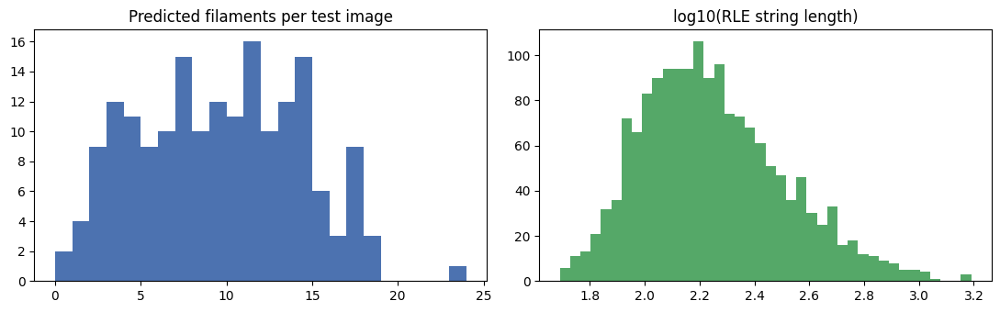

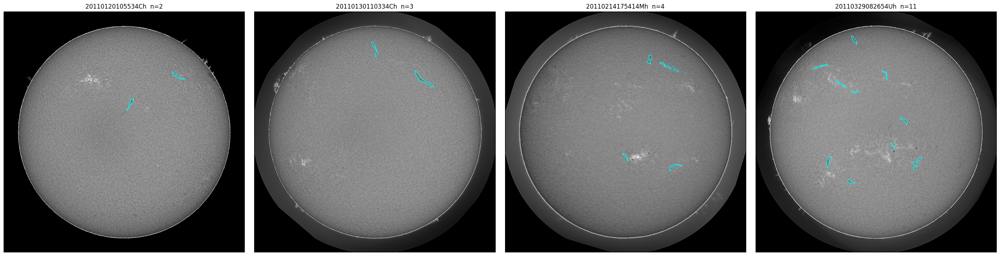

Saved: /kaggle/working/submission.csv
fold0_best_weights.pt saved | epoch 12
fold0_last_weights.pt saved | epoch 12


In [38]:
# ---------------- Free leftover training memory ----------------
for n in ["model", "opt", "sched", "scaler"]:
    globals().pop(n, None)
gc.collect(); torch.cuda.empty_cache()

# ---------------- Load model (offline-safe: no pretrained download) ----------------
def load_model(path):
    m = smp.Unet(ENCODER, encoder_weights=None, in_channels=1, classes=1)
    ck = torch.load(path, map_location="cpu", weights_only=False)   # our own checkpoint
    m.load_state_dict(ck["model"] if isinstance(ck, dict) and "model" in ck else ck)
    return m.to(dev).to(memory_format=torch.channels_last).eval()

models = [load_model(f"{WORK}/ckpt/{TAG}_best.pt")]
print(f"Loaded {len(models)} model(s) | post-processing: {PP}")

@torch.no_grad()
def predict_tta(models, img_u8, tta=True):
    x = torch.from_numpy((img_u8.astype(np.float32) - MEAN) / STD)[None, None].to(dev)
    flips = [(), (3,), (2,), (2, 3)] if tta else [()]
    acc, n = 0, 0
    for m in models:
        for f in flips:
            xi = torch.flip(x, f) if f else x
            with torch.autocast("cuda", dtype=torch.float16):
                p = torch.sigmoid(m(xi.contiguous(memory_format=torch.channels_last)).float())
            acc = acc + (torch.flip(p, f) if f else p); n += 1
    return (acc / n)[0, 0]

def to_u8(p):
    return (p * 255).round().byte().cpu().numpy()

# ---------------- Does TTA help? (validation fold, same post-processing) ----------------
t0 = time.time()
vp_tta = np.stack([to_u8(predict_tta(models, X[i], tta=True)) for i in va_list])
print(f"TTA validation inference: {time.time() - t0:.0f}s")
cmp_tta = pd.DataFrame({
    "single pass": pp_summary(score_pp(vp, va_list, **PP)),
    "flip TTA": pp_summary(score_pp(vp_tta, va_list, **PP)),
}).T
print("\n=== Single pass vs flip TTA (fold 0 validation) ===")
display(cmp_tta.round(4))
USE_TTA = bool(cmp_tta.loc["flip TTA", "PQ"] >= cmp_tta.loc["single pass", "PQ"])
print("Using TTA:", USE_TTA)

# ---------------- Sample submission format (if provided) ----------------
sample_sub = glob.glob("/kaggle/input/**/sample_submission*.csv", recursive=True)
if sample_sub:
    print("\nSample submission found:", sample_sub[0])
    display(pd.read_csv(sample_sub[0]).head(3))
else:
    print("\nNo sample_submission file found; using columns filament_id, segmentation_rle")

# ---------------- Test inference ----------------
def counts_str(r):
    c = r["counts"]
    return c.decode() if isinstance(c, bytes) else c

def fallback_rle(p8, low=0.5):
    m = (p8 > int(low * 255)).astype(np.uint8)
    n, lab, stats, _ = cv2.connectedComponentsWithStats(m, connectivity=8)
    if n <= 1:
        return []
    k = 1 + int(np.argmax(stats[1:, cv2.CC_STAT_AREA]))
    return [mu.encode(np.asfortranarray((lab == k).astype(np.uint8)))]

rows, per_img, n_fallback, n_empty = [], [], 0, 0
test_cache = {}
t0 = time.time()
for f in test_files:
    stem = os.path.splitext(os.path.basename(f))[0]
    im = cv2.imread(f, cv2.IMREAD_GRAYSCALE)
    assert im is not None and im.shape == (H, W), (stem, None if im is None else im.shape)
    p8 = to_u8(predict_tta(models, im, tta=USE_TTA))
    rl = pp_rles(p8, **PP)
    if not rl:
        rl = fallback_rle(p8, PP["low"]); n_fallback += len(rl) > 0
        if not rl: n_empty += 1
    for k, r in enumerate(rl, 1):
        rows.append({"filament_id": f"{stem}_{k}", "segmentation_rle": counts_str(r)})
    per_img.append({"stem": stem, "instrument": stem[14:16], "n_pred": len(rl)})
    if len(test_cache) < 4: test_cache[stem] = (im, rl)
print(f"Test inference: {len(test_files)} images in {time.time() - t0:.0f}s")

sub = pd.DataFrame(rows)
sub.to_csv(f"{WORK}/submission.csv", index=False)
pi = pd.DataFrame(per_img)

# ---------------- Validation of the file ----------------
chk = {
    "rows (filaments)": len(sub),
    "test images": len(test_files),
    "images with >=1 row": int((pi["n_pred"] > 0).sum()),
    "images fallback-only": int(n_fallback),
    "images with no prediction": int(n_empty),
    "unique ids": bool(sub["filament_id"].is_unique),
    "quotes in RLE": int(sub["segmentation_rle"].str.contains("['\"]").sum()),
    "mean filaments / image": round(pi["n_pred"].mean(), 2),
    "train GT mean / record": round(img_df["n_filaments"].mean(), 2),
}
# Re-read from disk: same rows, ids map to real test images
back = pd.read_csv(f"{WORK}/submission.csv", dtype=str, keep_default_na=False)
test_stems = {os.path.splitext(os.path.basename(f))[0] for f in test_files}
chk["re-read rows match"] = bool(len(back) == len(sub) and (back["segmentation_rle"].values == sub["segmentation_rle"].values).all())
chk["all ids map to test images"] = bool(back["filament_id"].str.rsplit("_", n=1).str[0].isin(test_stems).all())

print("\n=== Submission checks ===")
display(pd.DataFrame(chk.items(), columns=["check", "value"]))
assert chk["unique ids"] and chk["quotes in RLE"] == 0 and chk["re-read rows match"] and chk["all ids map to test images"]
if n_empty:
    print(f"NOTE: {n_empty} test image(s) have no predicted filament and therefore no row.")

# RLE round trip on a few random rows
ok = []
for _, r in sub.sample(5, random_state=0).iterrows():
    d = mu.decode({"size": [H, W], "counts": r["segmentation_rle"].encode()})
    ok.append(int(d.sum()) > 0)
print("RLE round-trip decodes to non-empty masks:", all(ok))

print("\n=== Predicted filaments per image, by instrument ===")
display(pi.groupby("instrument")["n_pred"].describe().round(2))
display(sub.head(3))

fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
ax[0].hist(pi["n_pred"], bins=range(0, int(pi["n_pred"].max()) + 2), color="#4c72b0"); ax[0].set_title("Predicted filaments per test image")
ax[1].hist(np.log10(sub["segmentation_rle"].str.len()), bins=40, color="#55a868"); ax[1].set_title("log10(RLE string length)")
plt.tight_layout(); plt.show()

# ---------------- Visual: predicted contours on 4 test images ----------------
fig, axes = plt.subplots(1, 4, figsize=(28, 7))
for ax_, (stem, (im, rl)) in zip(axes, test_cache.items()):
    ax_.imshow(im[::2, ::2], cmap="gray")
    for r in rl:
        m = cv2.resize(mu.decode(r), (1024, 1024), interpolation=cv2.INTER_NEAREST)
        for cnt in cv2.findContours(m, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)[0]:
            ax_.plot(cnt[:, 0, 0], cnt[:, 0, 1], color="cyan", lw=1)
    ax_.set_title(f"{stem}  n={len(rl)}"); ax_.axis("off")
plt.tight_layout(); plt.savefig(f"{WORK}/figs/test_predictions_baseline.png", dpi=55); plt.show()
print("Saved:", f"{WORK}/submission.csv")

# ---------------- Weights-only copies (load under PyTorch's safe default) ----------------
for kind in ["best", "last"]:
    p = f"{WORK}/ckpt/{TAG}_{kind}.pt"
    if os.path.exists(p):
        ck = torch.load(p, map_location="cpu", weights_only=False)
        sd = ck["model"] if isinstance(ck, dict) and "model" in ck else ck
        torch.save(sd, f"{WORK}/ckpt/{TAG}_{kind}_weights.pt")
        print(f"{TAG}_{kind}_weights.pt saved | epoch {ck.get('epoch') if isinstance(ck, dict) else None}")

In [ ]:
import zipfile, glob, shutil, time, json, os, pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

WORK = "/kaggle/working"
CACHE = "/kaggle/temp" if os.path.isdir("/kaggle/temp") else "/tmp"
INCLUDE_CKPT = False  # False = smaller zip (no model weights)
SHOW_FIGS = True      # True = also display every figure inline

G = globals()
STAMP = time.strftime("%Y%m%d_%H%M")
PKG = f"solar_filament_run_{STAMP}"
STAGE = f"{CACHE}/{PKG}"
shutil.rmtree(STAGE, ignore_errors=True)
for d in ["tables", "figures", "config"]:
    os.makedirs(f"{STAGE}/{d}", exist_ok=True)
for old in glob.glob(f"{WORK}/solar_filament_run_*.zip"):
    os.remove(old)

# ---------------- Tables -> CSV (each guarded) ----------------
tables, skipped = [], []
def T(name, fn, desc, index=True):
    try:
        obj = fn()
        df = obj if isinstance(obj, pd.DataFrame) else pd.DataFrame(obj)
        df.to_csv(f"{STAGE}/tables/{name}.csv", index=index)
        tables.append((name, desc))
    except Exception as e:
        skipped.append((name, type(e).__name__))

T("01_environment", lambda: pd.DataFrame(env.items(), columns=["item", "value"]), "Python/PyTorch/GPU environment", False)
T("02_dataset_paths", lambda: paths, "Data locations and train/test image counts", False)
T("03_annotation_geometry", lambda: ann_df[["area", "bw", "bh", "bbox_aspect", "bbox_fill"]].describe(percentiles=[.05, .25, .5, .75, .95]).round(2), "Filament area and bounding-box statistics")
T("04_category_counts", lambda: ann_df["cat"].value_counts().to_frame("count"), "Annotation category counts")
T("05_annotators_per_image", lambda: img_df.groupby("stem")["annotator"].nunique().value_counts().sort_index().rename("n_images").to_frame(), "Images by number of annotators")
T("06_fold_assignment", lambda: stem_df[["stem", "date", "instrument", "n_ann", "fold"]], "Image-to-fold map (grouped by observation date)", False)
T("07_fold_summary", lambda: fold_tbl, "Images, dates and instruments per fold")
T("08_label_agreement", lambda: lab.groupby("n_ann").agg(images=("n_ann", "size"), fg_pct=("fg_any_pct", "mean"), frac_pixels_all_agree=("pixel_agreement", "mean")).round(3), "Foreground rate and pixel agreement by number of annotators")
T("09_instrument_intensity", lambda: bright, "Image intensity by GONG site")
T("10_human_ceiling_by_instrument", lambda: ceil.groupby("instrument").agg(pairs=("pq", "size"), PQ=("pq", "mean"), SQ=("sq", "mean"), RQ=("rq", "mean")).round(3), "Annotator-vs-annotator PQ by site")
T("11_human_ceiling_pairs", lambda: ceil, "Annotator-vs-annotator PQ for every pair", False)
T("12_crop_foreground_stats", lambda: stats, "Foreground share of training crops")
T("13_training_history_fold0", lambda: pd.DataFrame(hist), "Epoch-by-epoch loss and validation metrics", False)
T("14_validation_per_record_baseline", lambda: best_df, "Per-record validation metrics, baseline post-processing", False)
T("15_validation_by_instrument_baseline", lambda: best_df.groupby("instrument").agg(records=("pq", "size"), PQ=("pq", "mean"), SQ=("sq", "mean"), RQ=("rq", "mean"), Dice=("dice", "mean")).round(3), "Validation metrics by site, baseline")
T("16_postproc_A_hysteresis", lambda: A, "Post-processing sweep A: hysteresis", False)
T("17_postproc_B_min_area", lambda: B, "Post-processing sweep B: minimum area", False)
T("18_postproc_C_closing", lambda: C, "Post-processing sweep C: morphological closing", False)
T("19_baseline_vs_tuned", lambda: cmp_, "Baseline vs tuned post-processing")
T("20_tuned_by_instrument", lambda: tuned_df.groupby("instrument").agg(records=("pq", "size"), PQ=("pq", "mean"), SQ=("sq", "mean"), RQ=("rq", "mean")).round(3), "Validation metrics by site, tuned")
T("21_tta_comparison", lambda: cmp_tta, "Single pass vs flip TTA")
T("22_submission_checks", lambda: pd.DataFrame(chk.items(), columns=["check", "value"]), "Submission file format checks", False)
T("23_test_predictions_per_image", lambda: pi, "Predicted filament count per test image", False)
T("24_test_count_by_instrument", lambda: pi.groupby("instrument")["n_pred"].describe().round(2), "Predicted filaments per image, by site")

# ---------------- Figures: numbered, captioned ----------------
FIGS = [
 ("audit_stats.png", "Annotation audit: counts, area, aspect, bbox, fill, records per year"),
 ("gt_overlays.png", "Ground-truth polygon overlays on six training images"),
 ("instruments.png", "One example image from each GONG site"),
 ("consensus.png", "Three annotators and the soft consensus target"),
 ("train_batch.png", "Training batch: crops with soft consensus targets"),
 ("overfit_check.png", "Single-batch overfit sanity test"),
 ("training_curves_fold0.png", "Fold 0 training loss and validation PQ/SQ/RQ/Dice"),
 ("val_predictions_fold0.png", "Fold 0 validation: annotator (green) vs model (red)"),
 ("pp_tuning_fold0.png", "Post-processing sweeps"),
 ("pp_overlay_fold0.png", "Annotator vs baseline and tuned post-processing"),
 ("zoom_gallery_fold0.png", "Zoomed crops of the largest filaments: image, annotator, model"),
 ("test_predictions_baseline.png", "Test-set predictions (cyan contours)"),
]
figs_saved = []
for n, (src, cap) in enumerate(FIGS, 1):
    p = f"{WORK}/figs/{src}"
    if os.path.exists(p):
        new = f"{n:02d}_{src}"
        shutil.copy(p, f"{STAGE}/figures/{new}"); figs_saved.append((new, cap))
    else:
        skipped.append((src, "figure file not found"))
known = {s for s, _ in FIGS}
for p in sorted(glob.glob(f"{WORK}/figs/*.png")):
    if os.path.basename(p) not in known:
        new = f"extra_{os.path.basename(p)}"
        shutil.copy(p, f"{STAGE}/figures/{new}"); figs_saved.append((new, "Additional figure"))

# ---------------- Config, requirements, post-processing ----------------
cfg = {k: G.get(k) for k in ["ENCODER", "FOLD", "CROP", "EPOCHS", "EVAL_EVERY", "MEAN", "STD", "SEED", "THR", "MIN_AREA", "USE_TTA"]}
cfg["post_processing"] = G.get("PP")
cfg["pretrained_weights"] = "imagenet (training only; inference loads checkpoints)"
json.dump(cfg, open(f"{STAGE}/config/config.json", "w"), indent=2, default=str)
if os.path.exists(f"{WORK}/requirements.txt"):
    shutil.copy(f"{WORK}/requirements.txt", f"{STAGE}/config/requirements.txt")

# ---------------- README ----------------
res = []
try: res.append(f"- Fold {G['FOLD']} validation, baseline post-processing: PQ {G['best']['pq']:.4f} at epoch {G['best']['epoch']}")
except Exception: pass
try:
    t = G["cmp_"].loc["tuned"]
    res.append(f"- Tuned post-processing {G['PP']}: PQ {t['PQ']:.4f}, SQ {t['SQ']:.4f}, RQ {t['RQ']:.4f}; TP/FP/FN {int(t['TP'])}/{int(t['FP'])}/{int(t['FN'])}")
except Exception: pass
try: res.append(f"- Human annotator-vs-annotator PQ ceiling: {G['ceil']['pq'].mean():.3f}")
except Exception: pass
try: res.append(f"- Flip TTA vs single pass (PQ): {G['cmp_tta'].loc['flip TTA','PQ']:.4f} vs {G['cmp_tta'].loc['single pass','PQ']:.4f}")
except Exception: pass

readme = f"""# Solar Filament Segmentation Challenge 2026 - run package ({STAMP})

Automatic segmentation of solar filaments in GONG H-Alpha images (MAGFiLO ground truth). Primary metric: Panoptic Quality (PQ).

## Results
{chr(10).join(res) if res else "- (no results available when this package was built)"}
- Caveat: post-processing was tuned on the same validation images it is scored on, so these numbers are optimistic.

## Method (current baseline)
- Data: 707 training images (2048x2048, 8-bit), 1,154 annotation records, 8,199 polygons.
- Targets: soft consensus mask (mean of annotator masks). Split: 5 folds grouped by observation date.
- Model: U-Net, ResNet34 encoder (ImageNet init), BCE + soft Dice, fp16, AdamW + OneCycle, 768 px crops.
- Post-processing: threshold, morphological closing, connected components, minimum-area filter (PQ at IoU > 0.5).

## Folders
- `figures/` numbered figures | `tables/` CSV tables | `models/` checkpoints and weights-only copies
- `submission/` submission.csv | `config/` config.json and requirements.txt | `MANIFEST.csv` all files | `code/` add the notebook here

## Figure index
{chr(10).join(f"- `{n}`: {c}" for n, c in figs_saved)}

## Table index
{chr(10).join(f"- `{n}.csv`: {d}" for n, d in tables)}

## Not available when packaged
{chr(10).join(f"- {n}: {why}" for n, why in skipped) if skipped else "- none"}

## Inference without internet
Build `smp.Unet(encoder_weights=None)` and load a checkpoint from `models/` (the `*_weights.pt` files load with PyTorch's safe default).
"""
open(f"{STAGE}/README.md", "w").write(readme)

# ---------------- Zip ----------------
zpath = f"{WORK}/{PKG}.zip"
with zipfile.ZipFile(zpath, "w", zipfile.ZIP_DEFLATED) as z:
    for root, _, files in os.walk(STAGE):
        for f in files:
            full = os.path.join(root, f)
            z.write(full, arcname=f"{PKG}/{os.path.relpath(full, STAGE)}")
    if INCLUDE_CKPT:
        for f in sorted(glob.glob(f"{WORK}/ckpt/*")):
            z.write(f, arcname=f"{PKG}/models/{os.path.basename(f)}")
    if os.path.exists(f"{WORK}/submission.csv"):
        z.write(f"{WORK}/submission.csv", arcname=f"{PKG}/submission/submission.csv")
    z.writestr(f"{PKG}/code/PUT_NOTEBOOK_HERE.txt", "Kaggle: File > Download notebook, then add the .ipynb here.\n")

with zipfile.ZipFile(zpath) as z:
    man = pd.DataFrame([(i.filename.replace(PKG + "/", ""), round(i.file_size / 1e6, 2)) for i in z.infolist()], columns=["file", "MB"])
with zipfile.ZipFile(zpath, "a") as z:
    z.writestr(f"{PKG}/MANIFEST.csv", man.to_csv(index=False))

print(f"=== {zpath}  ({os.path.getsize(zpath) / 1e6:.0f} MB) ===")
print(f"{len(figs_saved)} figures | {len(tables)} tables | checkpoints included: {INCLUDE_CKPT}")
if skipped:
    print("\nNot available:")
    display(pd.DataFrame(skipped, columns=["item", "reason"]))
display(man)

# ---------------- Optional: show the figures inline ----------------
if SHOW_FIGS:
    for n, c in figs_saved:
        img = mpimg.imread(f"{STAGE}/figures/{n}")
        plt.figure(figsize=(14, 14 * img.shape[0] / img.shape[1]))
        plt.imshow(img); plt.axis("off"); plt.title(f"{n}: {c}", fontsize=10); plt.show()